# SATX House Hack Model — Exploratory Data Analysis

This notebook examines every raw data source the scoring model relies on.

**The goal is not to produce charts for their own sake.** Each section answers a specific question that either validates a model assumption or challenges it:

| Source | Key Question |
|--------|-------------|
| ZHVI (home values) | Where does the $450k ceiling cut? Is the stability metric meaningful? |
| ZORI (rents) | Where does the 7.2% yield floor land? Are there natural market clusters? |
| Census (demographics) | Are the owner-occ and income filter thresholds defensible? |
| SAPD Crime (CFS) | How much of 5.3M calls is actually crime? Does the Problem filter hold up? |
| Cross-source | How many ZIPs survive each stage? Where does the funnel narrow? |

---

**Run order:** Top to bottom. Each section loads fresh from `data/raw/` and does not depend on the main pipeline having run first.

**Prerequisite:** The three Zillow/SimpleMaps files must be downloaded (see README). Census and crime data are auto-fetched by the model on first run.

## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT     = Path('..').resolve()
DATA_RAW = ROOT / 'data' / 'raw'
SRC      = ROOT / 'src'
sys.path.insert(0, str(SRC))

from config import (THRESHOLDS, CRIME_PERCENTILE_CUTOFF, YIELD_CAP,
                    ZHVI_STABILITY_YEARS, VIOLENT_CRIME_PROBLEMS)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

BAMC_COLOR = '#c0392b'
PASS_COLOR = '#27ae60'
FAIL_COLOR = '#e74c3c'
WARN_COLOR = '#f39c12'

print(f'Root: {ROOT}')
print(f'Raw data folder exists: {DATA_RAW.exists()}')
print(f'Files found: {[f.name for f in sorted(DATA_RAW.glob("*.csv"))]}')

Root: /Users/asan/workspace/personnal/satx_house_hack_model
Raw data folder exists: True
Files found: ['census_acs_raw.csv', 'sa_crime_raw.csv', 'uszips.csv', 'zillow_zhvi_zip.csv', 'zillow_zori_zip.csv']


---
## 1. Zillow Home Values (ZHVI)

**Source:** `zillow_zhvi_zip.csv` — monthly median home values by ZIP, SA metro.

**Two things this file powers:**
1. `median_home_value` — most recent value, used in the $450k ceiling filter and yield denominator
2. `zhvi_cov` — Coefficient of Variation over 5 years of monthly values, the price stability score

**Questions:**
- Where does the $450k ceiling cut in the distribution? Which specific ZIPs does it remove?
- What does appreciation look like across ZIPs over the last 3 years?
- Does the CoV stability metric spread ZIPs out meaningfully, or do they all cluster together?

In [2]:
# Load & filter to SA metro
zhvi_raw = pd.read_csv(DATA_RAW / 'zillow_zhvi_zip.csv', dtype={'RegionName': str})
zhvi_sa  = zhvi_raw[zhvi_raw['Metro'].str.contains('San Antonio', na=False)].copy()
zhvi_sa['zip'] = zhvi_sa['RegionName'].str.zfill(5)

date_cols = sorted([c for c in zhvi_sa.columns if c[:4].isdigit()])
zhvi_sa['current_value'] = pd.to_numeric(zhvi_sa[date_cols[-1]], errors='coerce')
zhvi_sa.dropna(subset=['current_value'], inplace=True)

print(f"SA ZIPs: {len(zhvi_sa)}")
print(f"Monthly data range: {date_cols[0]} to {date_cols[-1]} ({len(date_cols)} months)")
print(f"\nHome value distribution:")
print(zhvi_sa['current_value'].describe().apply(lambda x: f'${x:,.0f}'))

SA ZIPs: 106
Monthly data range: 2000-01-31 to 2026-01-31 (313 months)

Home value distribution:
count        $106
mean     $315,935
std      $146,055
min      $106,534
25%      $214,124
50%      $273,885
75%      $410,844
max      $905,220
Name: current_value, dtype: str


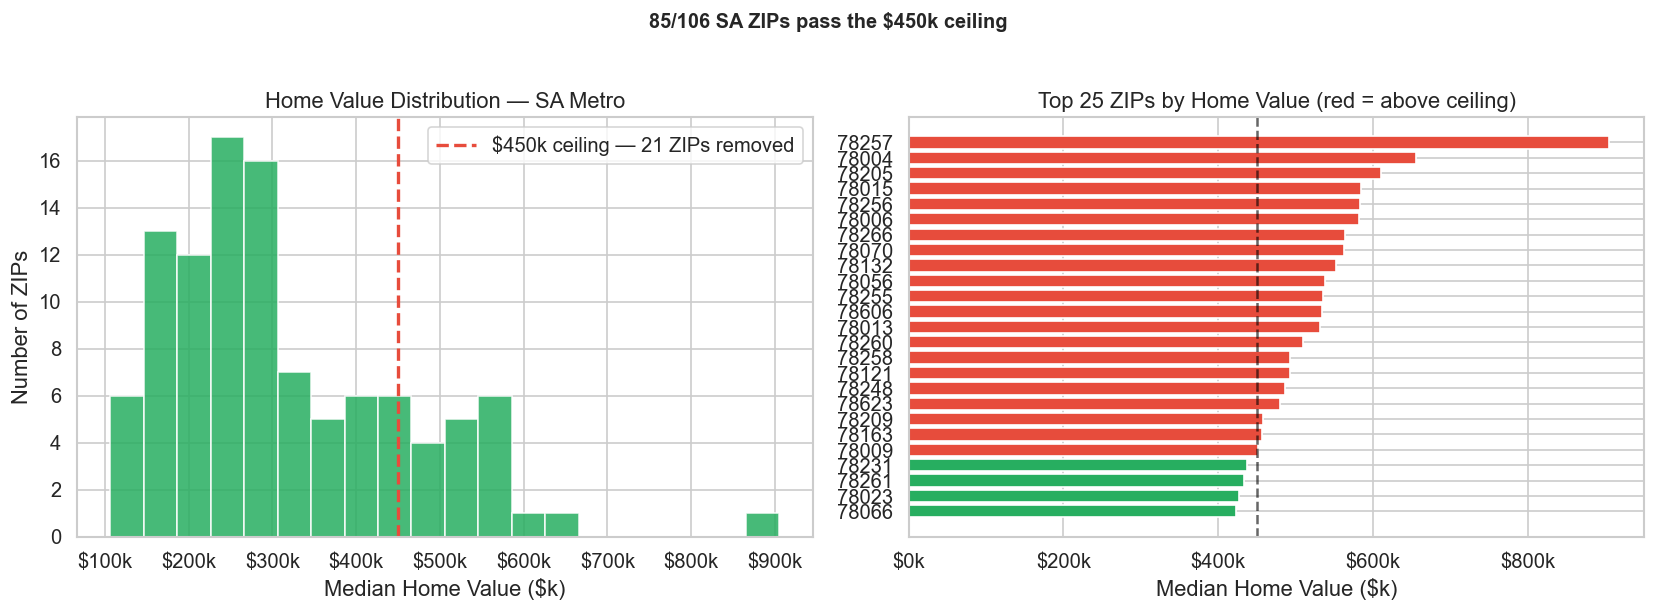

ZIPs above ceiling: ['78257', '78004', '78205', '78015', '78256', '78006', '78266', '78070', '78132', '78056', '78255', '78606', '78013', '78260', '78258', '78121', '78248', '78623', '78209', '78163', '78009']


In [3]:
# 1.1 Distribution with $450k ceiling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_val = THRESHOLDS['max_home_value']
n_pass  = (zhvi_sa['current_value'] <= max_val).sum()
n_fail  = (zhvi_sa['current_value'] >  max_val).sum()

ax = axes[0]
ax.hist(zhvi_sa['current_value'] / 1e3, bins=20, color=PASS_COLOR, edgecolor='white', alpha=0.85)
ax.axvline(max_val / 1e3, color=FAIL_COLOR, linewidth=2, linestyle='--',
           label=f'${max_val/1e3:.0f}k ceiling — {n_fail} ZIPs removed')
ax.set_xlabel('Median Home Value ($k)')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Home Value Distribution — SA Metro')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))

ax2 = axes[1]
sorted_df = zhvi_sa.sort_values('current_value', ascending=False).head(25)
bar_colors = [FAIL_COLOR if v > max_val else PASS_COLOR for v in sorted_df['current_value']]
ax2.barh(sorted_df['zip'], sorted_df['current_value'] / 1e3, color=bar_colors, edgecolor='white')
ax2.axvline(max_val / 1e3, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
ax2.set_xlabel('Median Home Value ($k)')
ax2.set_title('Top 25 ZIPs by Home Value (red = above ceiling)')
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))

plt.suptitle(f'{n_pass}/{len(zhvi_sa)} SA ZIPs pass the ${max_val/1e3:.0f}k ceiling',
             y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

above = sorted_df[sorted_df['current_value'] > max_val]['zip'].tolist()
print(f"ZIPs above ceiling: {above}")

**What to look for:** If ZIPs cluster just *above* the $450k line, the threshold may be cutting too aggressively and worth raising slightly. If the ZIPs above it are all clearly premium (Stone Oak, The Dominion, Boerne), the filter is doing its job.

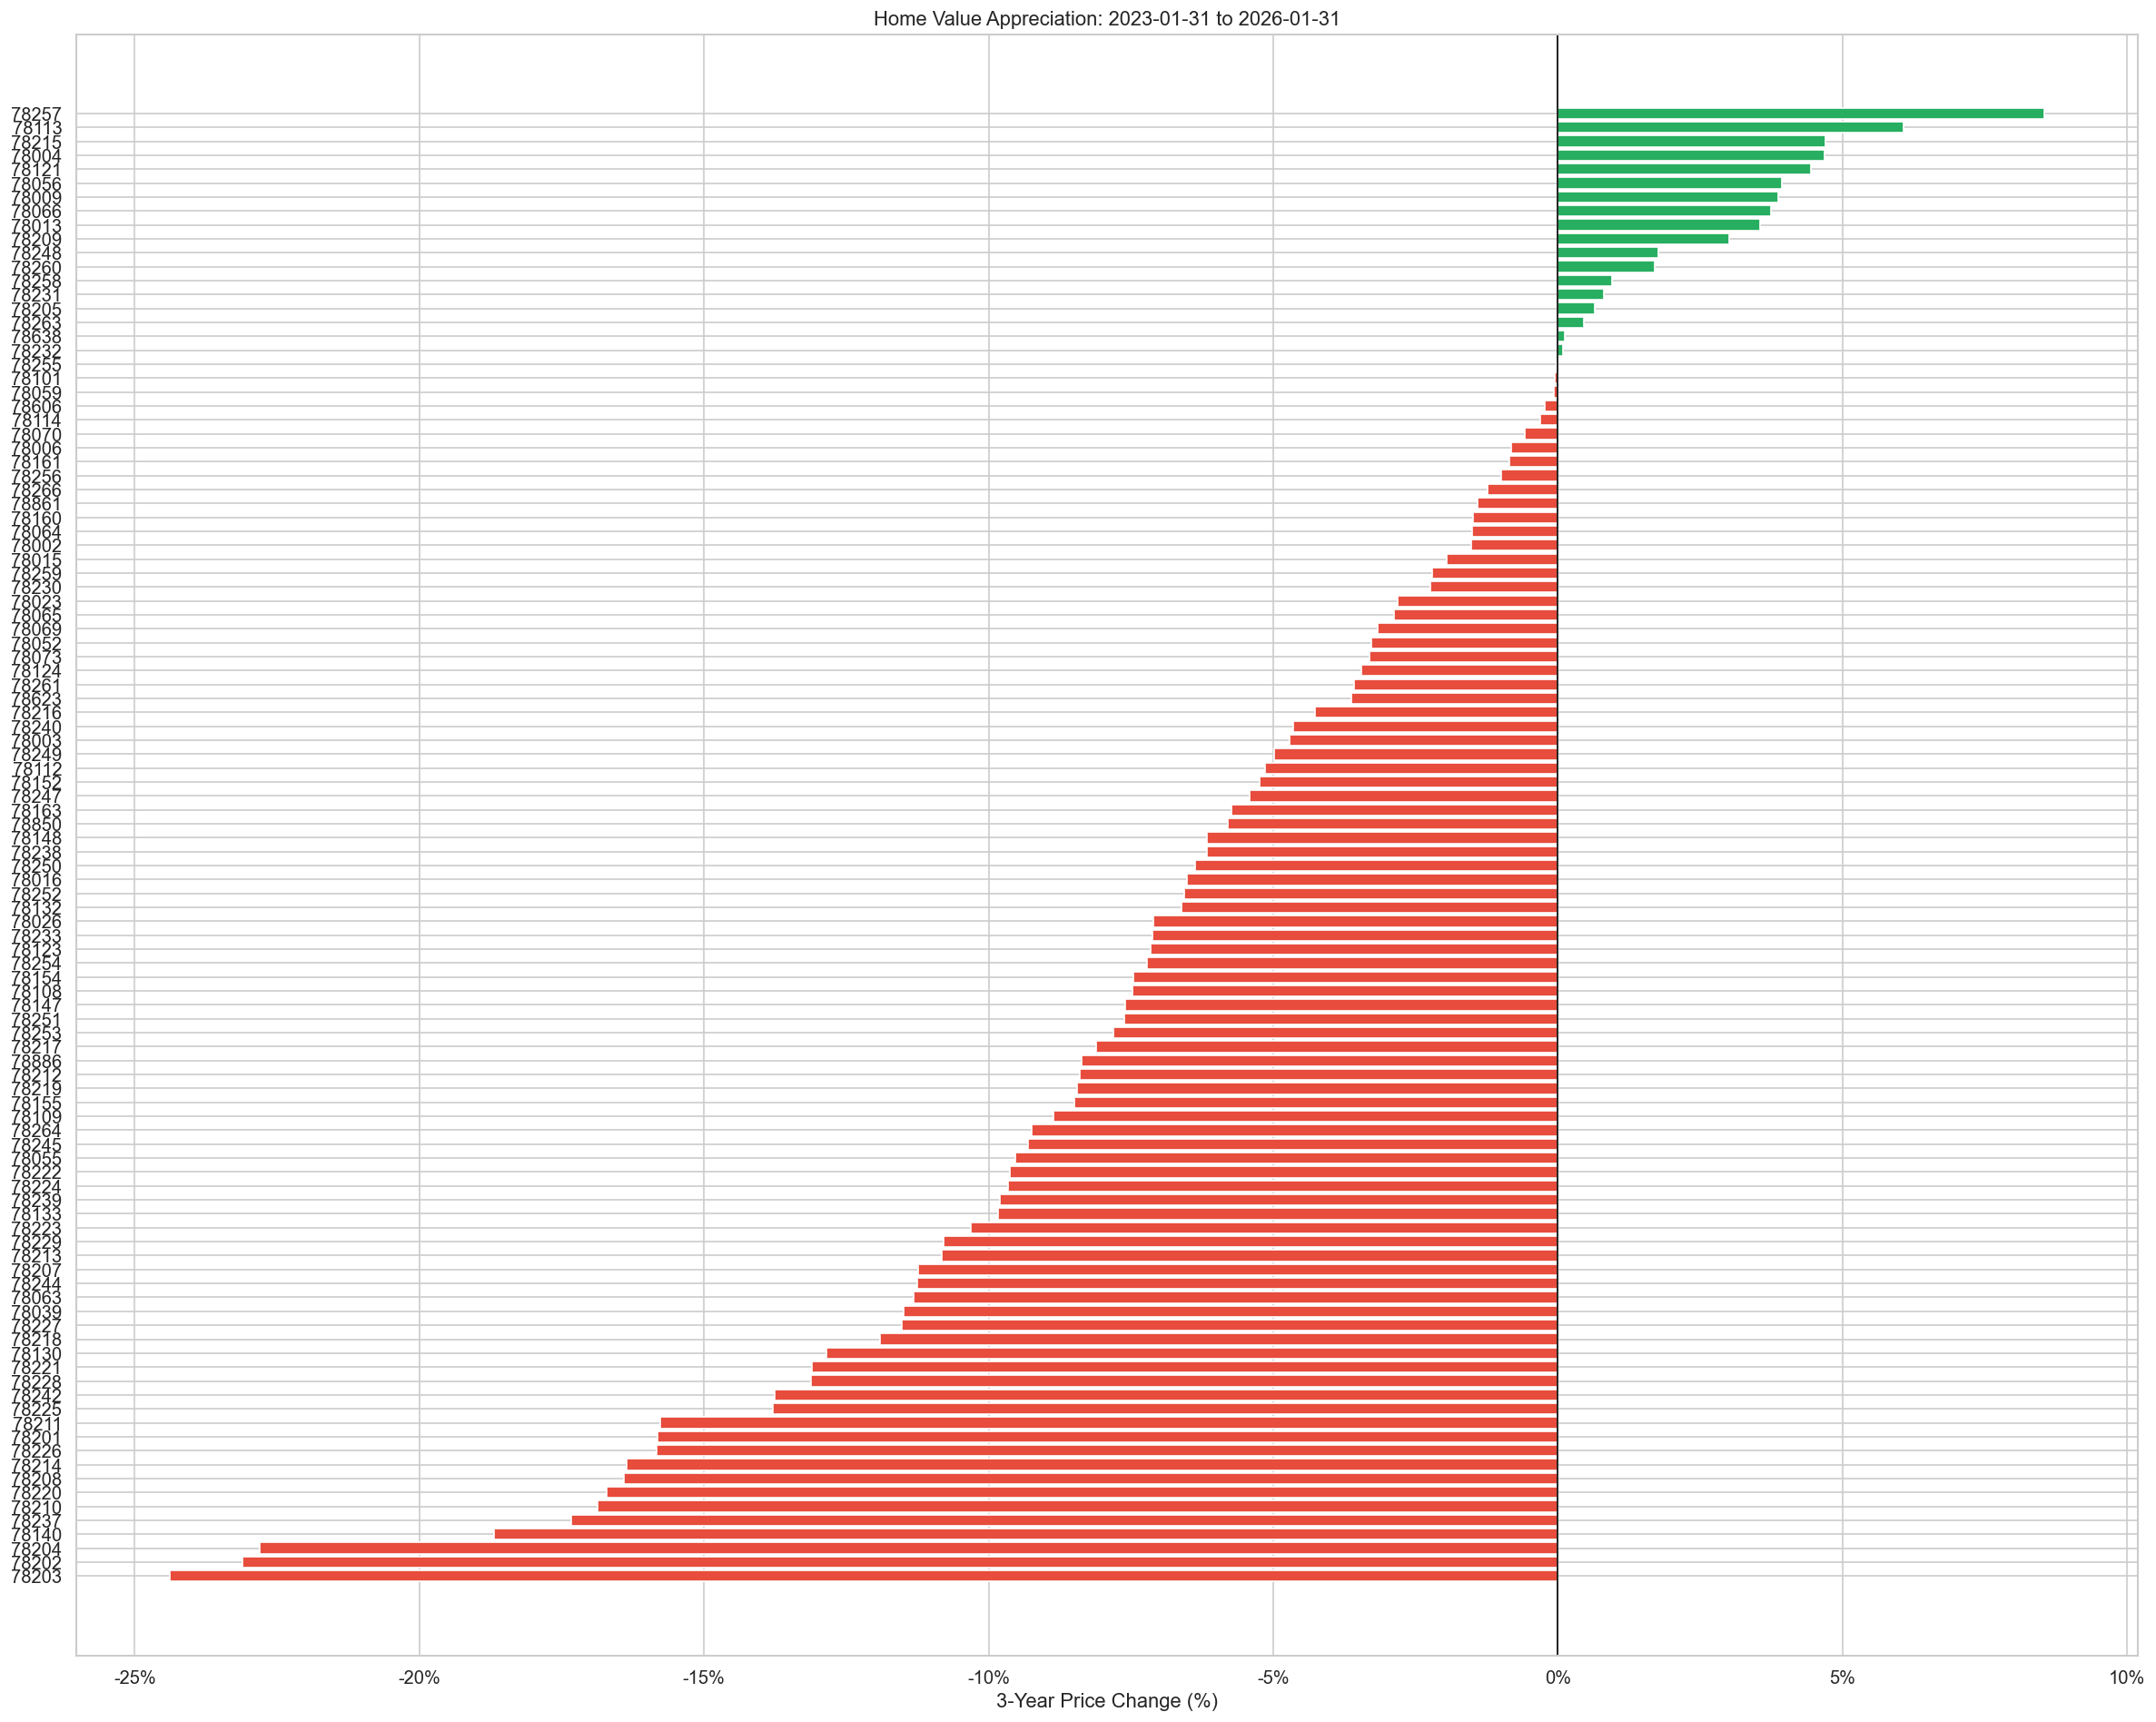

Median 3-year appreciation: -6.2%
ZIPs with negative 3yr return: 88

Top 5 by appreciation:
  zip  current_value  pct_change_3yr
78257  905219.680652        8.542560
78113  404339.701277        6.065490
78215  413012.579992        4.699926
78004  655910.848614        4.685171
78121  491992.608553        4.451903


In [4]:
# 1.2 3-year price appreciation by ZIP
months_3yr = 36
if len(date_cols) >= months_3yr + 1:
    col_3yr_ago = date_cols[-(months_3yr + 1)]
    zhvi_sa['value_3yr_ago']  = pd.to_numeric(zhvi_sa[col_3yr_ago], errors='coerce')
    zhvi_sa['pct_change_3yr'] = (zhvi_sa['current_value'] - zhvi_sa['value_3yr_ago']) / zhvi_sa['value_3yr_ago'] * 100
    zhvi_sa.dropna(subset=['pct_change_3yr'], inplace=True)

    fig, ax = plt.subplots(figsize=(20, 16))
    sorted_appr  = zhvi_sa.sort_values('pct_change_3yr')
    bar_colors_a = [PASS_COLOR if v >= 0 else FAIL_COLOR for v in sorted_appr['pct_change_3yr']]
    ax.barh(sorted_appr['zip'], sorted_appr['pct_change_3yr'], color=bar_colors_a, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('3-Year Price Change (%)')
    ax.set_title(f'Home Value Appreciation: {col_3yr_ago} to {date_cols[-1]}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.tight_layout()
    plt.show()

    print(f"Median 3-year appreciation: {zhvi_sa['pct_change_3yr'].median():.1f}%")
    print(f"ZIPs with negative 3yr return: {(zhvi_sa['pct_change_3yr'] < 0).sum()}")
    print(f"\nTop 5 by appreciation:")
    print(zhvi_sa.nlargest(5, 'pct_change_3yr')[['zip','current_value','pct_change_3yr']].to_string(index=False))
else:
    print("Not enough data for 3-year comparison.")

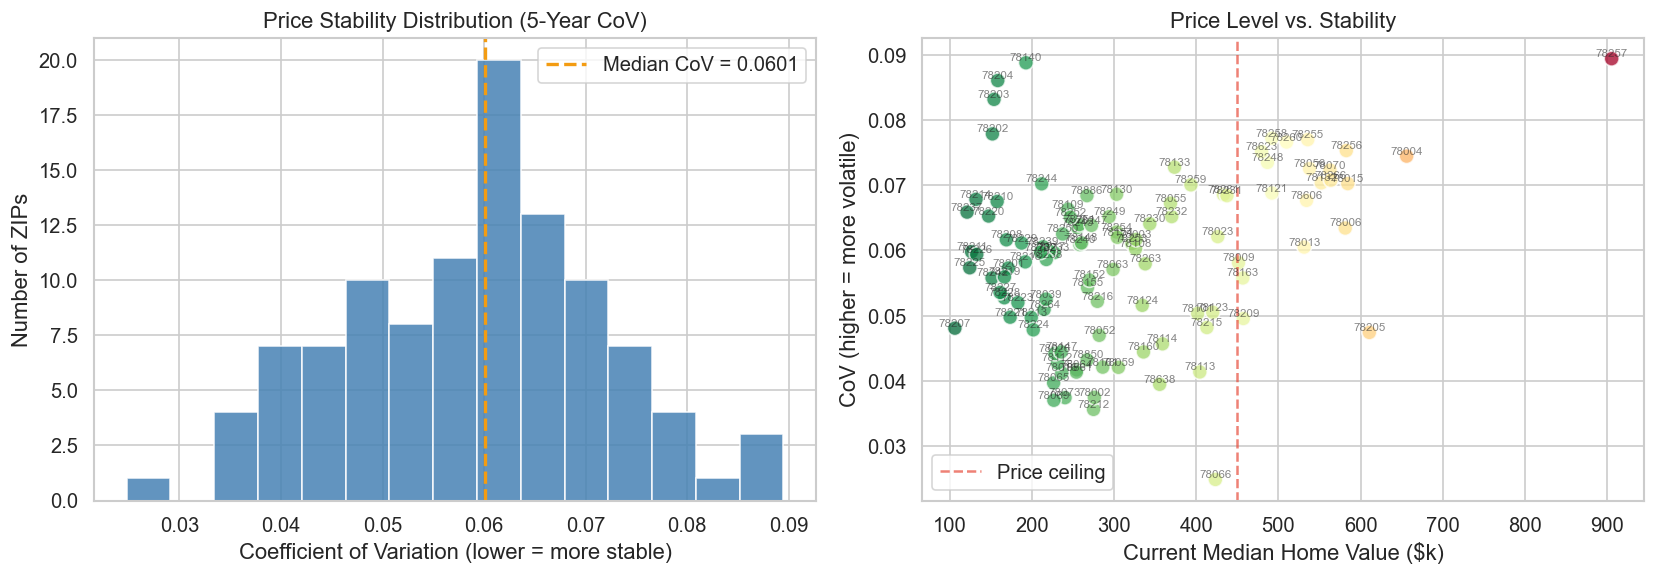

Most stable (lowest CoV):
  zip  current_value      cov
78066  423343.342313 0.024807
78212  275132.782675 0.035576
78069  226891.944268 0.036979
78073  240520.980747 0.037382
78002  276156.401189 0.037429

Least stable (highest CoV):
  zip  current_value      cov
78257  905219.680652 0.089486
78140  192969.521297 0.088857
78204  158669.379356 0.086124
78203  154125.949656 0.083229
78202  152194.455404 0.077923


In [5]:
# 1.3 Price stability — Coefficient of Variation
n_months = ZHVI_STABILITY_YEARS * 12
stability_cols = date_cols[-n_months:] if len(date_cols) >= n_months else date_cols

price_data = zhvi_sa.set_index('zip')[stability_cols].apply(pd.to_numeric, errors='coerce')
zhvi_sa_cov = (price_data.std(axis=1) / price_data.mean(axis=1)).rename('cov')
zhvi_sa = zhvi_sa.set_index('zip').join(zhvi_sa_cov).reset_index()
zhvi_sa.dropna(subset=['cov'], inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(zhvi_sa['cov'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(zhvi_sa['cov'].median(), color=WARN_COLOR, linewidth=2, linestyle='--',
           label=f"Median CoV = {zhvi_sa['cov'].median():.4f}")
ax.set_xlabel('Coefficient of Variation (lower = more stable)')
ax.set_ylabel('Number of ZIPs')
ax.set_title(f'Price Stability Distribution ({ZHVI_STABILITY_YEARS}-Year CoV)')
ax.legend()

ax2 = axes[1]
ax2.scatter(zhvi_sa['current_value'] / 1e3, zhvi_sa['cov'],
            c=zhvi_sa['current_value'], cmap='RdYlGn_r', alpha=0.75, edgecolors='white', s=80)
for _, row in zhvi_sa.iterrows():
    ax2.annotate(row['zip'], (row['current_value']/1e3, row['cov']),
                 fontsize=7, alpha=0.55, ha='center', va='bottom')
ax2.axvline(THRESHOLDS['max_home_value'] / 1e3, color=FAIL_COLOR,
            linestyle='--', linewidth=1.5, alpha=0.7, label='Price ceiling')
ax2.set_xlabel('Current Median Home Value ($k)')
ax2.set_ylabel('CoV (higher = more volatile)')
ax2.set_title('Price Level vs. Stability')
ax2.legend()

plt.tight_layout()
plt.show()

print("Most stable (lowest CoV):")
print(zhvi_sa.nsmallest(5, 'cov')[['zip','current_value','cov']].to_string(index=False))
print("\nLeast stable (highest CoV):")
print(zhvi_sa.nlargest(5, 'cov')[['zip','current_value','cov']].to_string(index=False))

**What to look for:** A wide spread in CoV is good — the stability score is discriminating meaningfully. If everything clusters tightly (e.g., all CoV between 0.08–0.12), the stability dimension adds little signal and its 10% weight may not be doing much. Also check: do high-CoV ZIPs show the highest 3-year appreciation? That would confirm the classic volatility/return tradeoff.

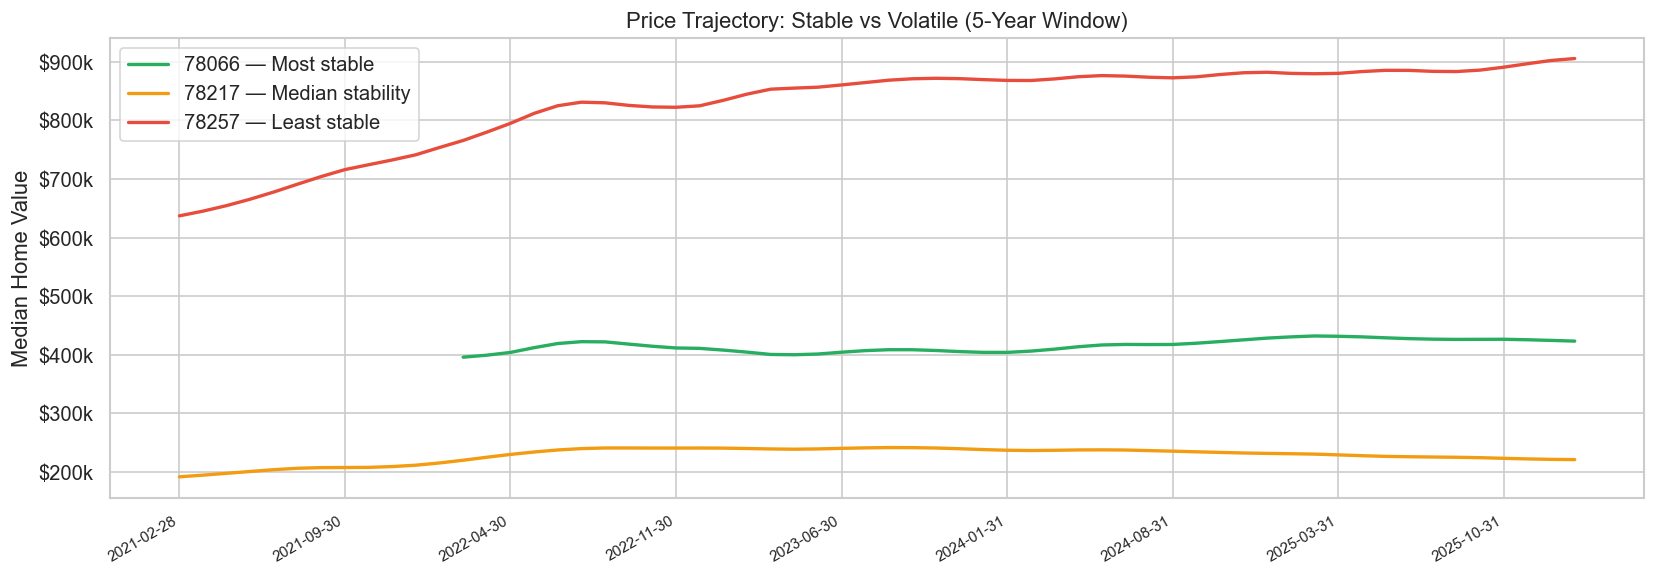

In [6]:
# 1.4 Price time-series: stable vs volatile ZIPs
most_stable  = zhvi_sa.nsmallest(1, 'cov')['zip'].values[0]
least_stable = zhvi_sa.nlargest(1, 'cov')['zip'].values[0]
median_zip   = zhvi_sa.iloc[(zhvi_sa['cov'] - zhvi_sa['cov'].median()).abs().argsort()[:1]]['zip'].values[0]

highlight = [(most_stable, 'Most stable', PASS_COLOR),
             (median_zip,  'Median stability', WARN_COLOR),
             (least_stable,'Least stable', FAIL_COLOR)]

fig, ax = plt.subplots(figsize=(14, 5))
for zip_code, label, color in highlight:
    row = zhvi_sa[zhvi_sa['zip'] == zip_code]
    if len(row) == 0: continue
    values = pd.to_numeric(row[stability_cols].iloc[0], errors='coerce')
    ax.plot(range(len(stability_cols)), values / 1e3,
            label=f'{zip_code} — {label}', color=color, linewidth=2)

tick_step = max(1, len(stability_cols) // 8)
ax.set_xticks(range(0, len(stability_cols), tick_step))
ax.set_xticklabels([stability_cols[i] for i in range(0, len(stability_cols), tick_step)],
                    rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.set_ylabel('Median Home Value')
ax.set_title(f'Price Trajectory: Stable vs Volatile ({ZHVI_STABILITY_YEARS}-Year Window)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Zillow Rents (ZORI) & Yield Analysis

**Source:** `zillow_zori_zip.csv` — monthly median asking rent by ZIP, SA metro.

**What this powers:** `median_rent` is combined with `median_home_value` to compute gross yield. The 7.2% yield floor is the hard filter most likely to be the model's tightest gate.

**Questions:**
- Where does the 7.2% yield floor actually land in the SA distribution?
- Are there ZIPs just below the floor that are borderline cuts vs. genuinely unviable?
- Is there a clean inverse relationship between home price and yield? (There should be.)
- Are asking rents trending up or down in the ZIPs that pass the floor?

SA ZIPs with rent data: 70

Rent distribution:
count       $70
mean     $1,482
std        $342
min        $906
25%      $1,243
50%      $1,435
75%      $1,642
max      $2,587
Name: median_rent, dtype: str

ZIPs with both price + rent: 69
Pass yield floor (7.2%): 27 | Fail: 42


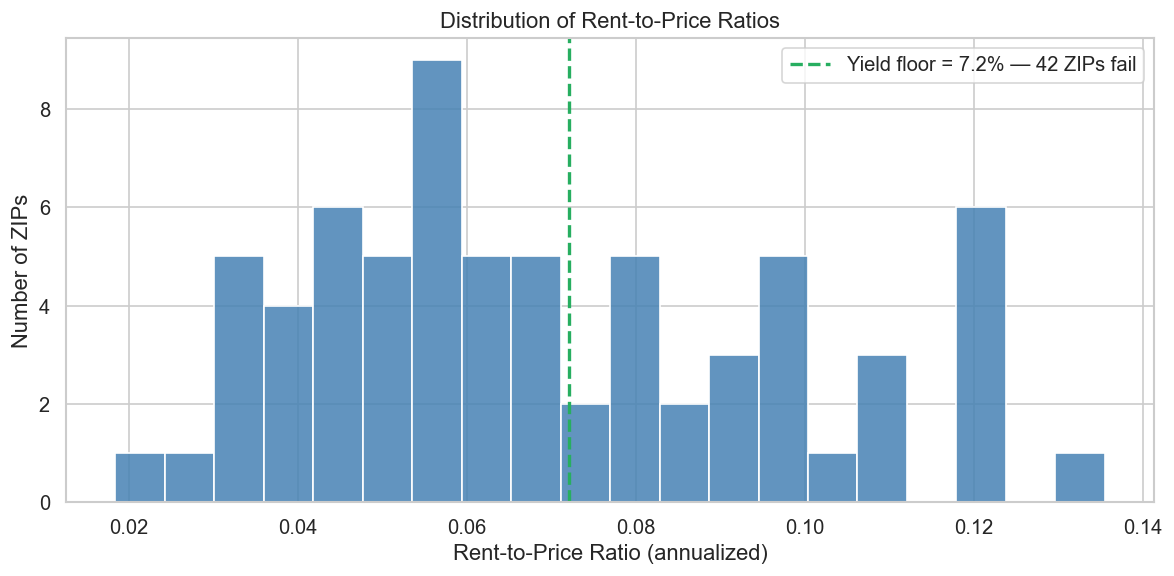

In [7]:
# Load ZORI
zori_raw = pd.read_csv(DATA_RAW / 'zillow_zori_zip.csv', dtype={'RegionName': str})
zori_sa  = zori_raw[zori_raw['Metro'].str.contains('San Antonio', na=False)].copy()
zori_sa['zip'] = zori_sa['RegionName'].str.zfill(5)

date_cols_zori = sorted([c for c in zori_sa.columns if c[:4].isdigit()])
zori_sa['median_rent'] = pd.to_numeric(zori_sa[date_cols_zori[-1]], errors='coerce')
zori_sa.dropna(subset=['median_rent'], inplace=True)

print(f"SA ZIPs with rent data: {len(zori_sa)}")
print(f"\nRent distribution:")
print(zori_sa['median_rent'].describe().apply(lambda x: f'${x:,.0f}'))

# Merge with ZHVI to compute yield
merged_yield = zhvi_sa[['zip','current_value','cov']].merge(
    zori_sa[['zip','median_rent']], on='zip', how='inner')
merged_yield['rent_to_price'] = (merged_yield['median_rent'] * 12) / merged_yield['current_value']

yield_floor  = THRESHOLDS['min_rent_to_price']
n_pass_yield = (merged_yield['rent_to_price'] >= yield_floor).sum()
n_fail_yield = (merged_yield['rent_to_price'] <  yield_floor).sum()

print(f"\nZIPs with both price + rent: {len(merged_yield)}")
print(f"Pass yield floor ({yield_floor:.1%}): {n_pass_yield} | Fail: {n_fail_yield}")

plt.figure(figsize=(10, 5))
sns.histplot(merged_yield['rent_to_price'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(yield_floor, color=PASS_COLOR, linewidth=2, linestyle='--',
            label=f'Yield floor = {yield_floor:.1%} — {n_fail_yield} ZIPs fail')
plt.xlabel('Rent-to-Price Ratio (annualized)')
plt.ylabel('Number of ZIPs')
plt.title('Distribution of Rent-to-Price Ratios')
plt.legend()
plt.tight_layout()
plt.show()

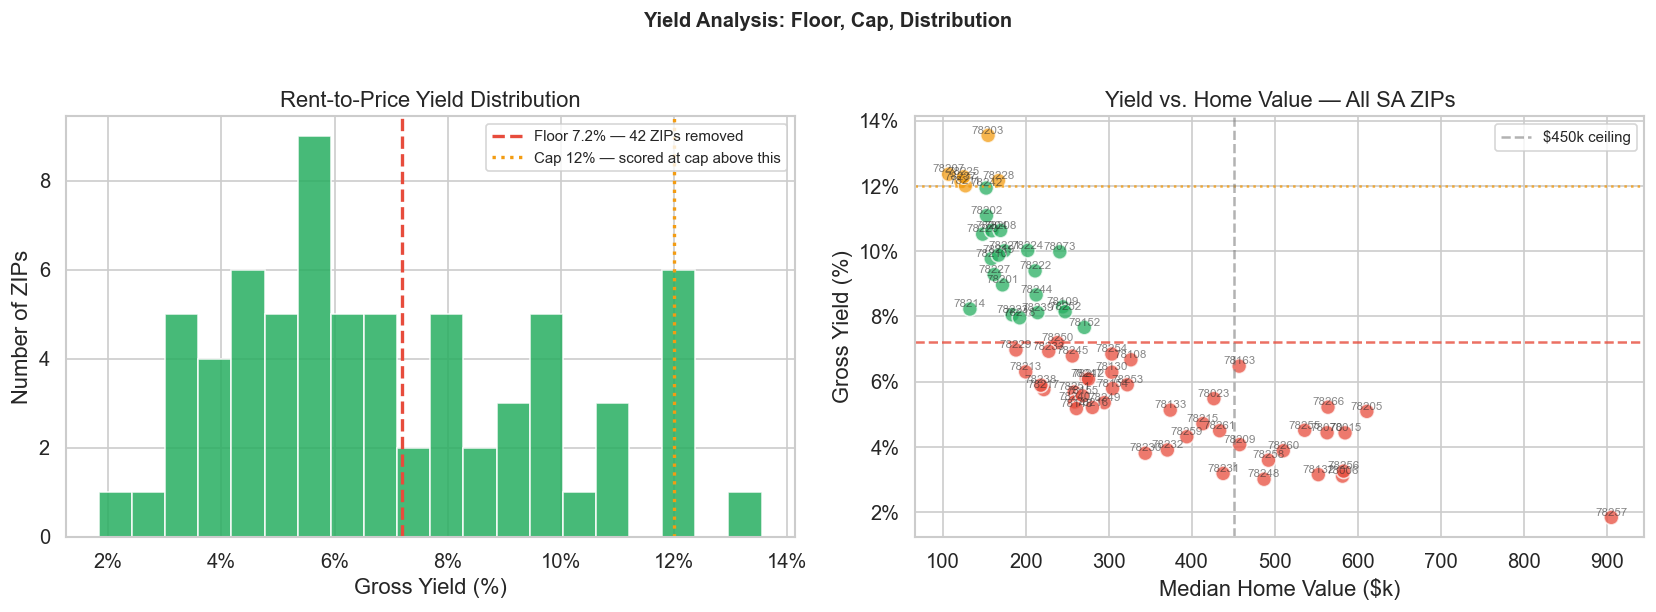


ZIPs within 15% below floor (borderline — review before accepting cut):
  zip  current_value  median_rent  rent_to_price
78250  237592.183396  1424.500000       0.071947
78229  187734.733875  1090.235709       0.069688
78233  227197.706357  1311.642726       0.069278
78254  303250.118441  1729.697193       0.068446
78245  255688.548687  1445.420560       0.067837
78108  326213.519969  1812.867003       0.066688
78163  456690.994123  2463.333333       0.064726
78213  199425.109371  1046.432586       0.062967
78130  303197.761272  1588.341721       0.062864


In [8]:
# 2.1 Yield distribution with floor and cap annotations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(merged_yield['rent_to_price'] * 100, bins=20,
        color=PASS_COLOR, edgecolor='white', alpha=0.85)
ax.axvline(yield_floor * 100, color=FAIL_COLOR, linewidth=2, linestyle='--',
           label=f'Floor {yield_floor:.1%} — {n_fail_yield} ZIPs removed')
ax.axvline(YIELD_CAP * 100, color=WARN_COLOR, linewidth=2, linestyle=':',
           label=f'Cap {YIELD_CAP:.0%} — scored at cap above this')
ax.set_xlabel('Gross Yield (%)')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Rent-to-Price Yield Distribution')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9)

ax2 = axes[1]
pt_colors = [
    FAIL_COLOR if v < yield_floor else WARN_COLOR if v > YIELD_CAP else PASS_COLOR
    for v in merged_yield['rent_to_price']
]
ax2.scatter(merged_yield['current_value'] / 1e3, merged_yield['rent_to_price'] * 100,
            c=pt_colors, alpha=0.75, edgecolors='white', s=80)
for _, row in merged_yield.iterrows():
    ax2.annotate(row['zip'], (row['current_value']/1e3, row['rent_to_price']*100),
                 fontsize=7, alpha=0.55, ha='center', va='bottom')
ax2.axhline(yield_floor * 100, color=FAIL_COLOR, linewidth=1.5, linestyle='--', alpha=0.8)
ax2.axhline(YIELD_CAP * 100,   color=WARN_COLOR, linewidth=1.5, linestyle=':', alpha=0.8)
ax2.axvline(THRESHOLDS['max_home_value'] / 1e3, color='gray',
            linewidth=1.5, linestyle='--', alpha=0.6, label='$450k ceiling')
ax2.set_xlabel('Median Home Value ($k)')
ax2.set_ylabel('Gross Yield (%)')
ax2.set_title('Yield vs. Home Value — All SA ZIPs')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.legend(fontsize=9)

plt.suptitle('Yield Analysis: Floor, Cap, Distribution', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Borderline ZIPs: within 15% of floor — most sensitive to threshold choice
borderline = merged_yield[
    (merged_yield['rent_to_price'] >= yield_floor * 0.85) &
    (merged_yield['rent_to_price'] <  yield_floor)
].sort_values('rent_to_price', ascending=False)
print(f"\nZIPs within 15% below floor (borderline — review before accepting cut):")
if len(borderline) > 0:
    print(borderline[['zip','current_value','median_rent','rent_to_price']].to_string(index=False))
else:
    print("None ==> All ZIPs either clearly pass or fail the yield floor.")

**What to look for:** The scatter plot should show a clean downward slope — expensive homes yield less. ZIPs that break that pattern (cheap home, low yield OR expensive home, high yield) are anomalies worth investigating. The borderline table shows ZIPs where a small threshold adjustment would change the outcome — if you recognize any as genuinely viable neighborhoods, lower the floor to `0.065`.

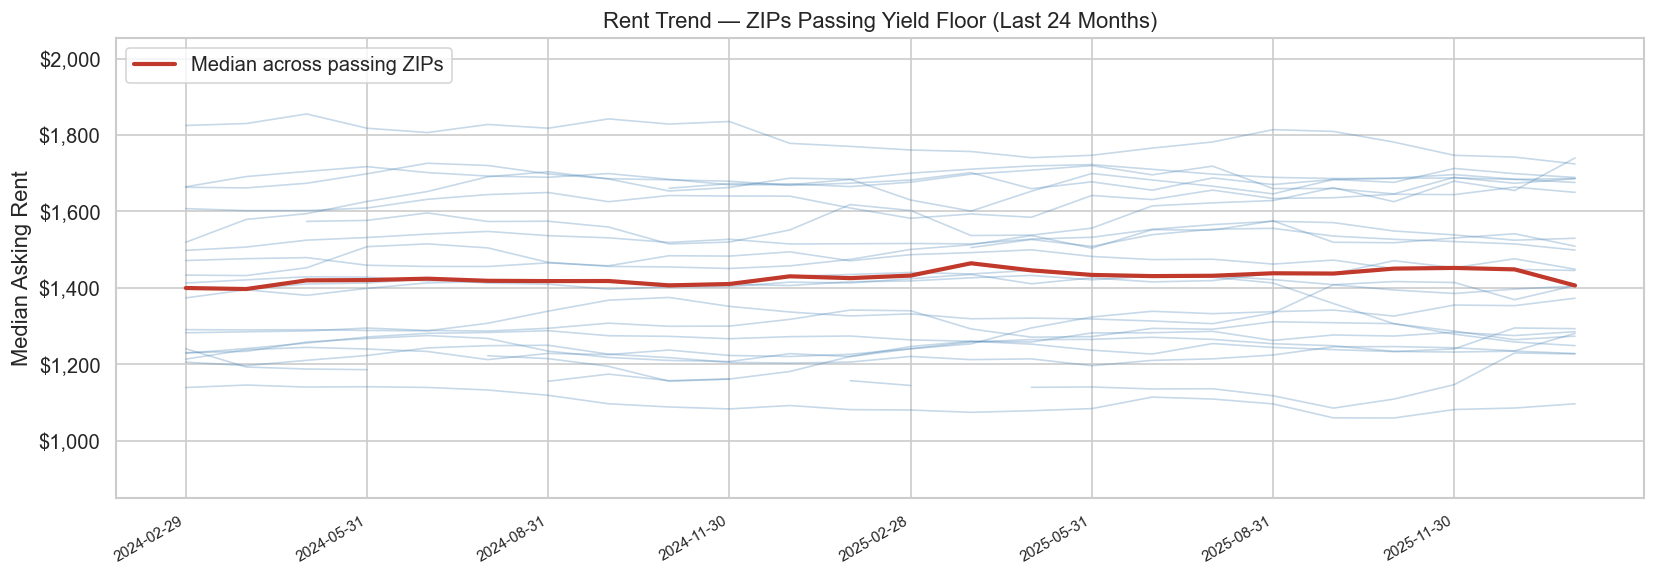

6-month rent drift summary:
count     61.0%
mean      -1.8%
std        3.5%
min      -10.8%
25%       -3.5%
50%       -2.2%
75%       -0.1%
max        8.0%
Name: rent_6m_pct, dtype: str

ZIPs with rent decline over 6 months: 48

Top 5 ZIPs by 6-month rent growth:
  zip  rent_6m_pct
78237     8.015223
78202     7.640726
78203     7.245200
78201     5.485896
78220     3.104961


In [9]:
# 2.2 Rent trend — last 24 months for yield-passing ZIPs
passing_zips   = merged_yield[merged_yield['rent_to_price'] >= yield_floor]['zip'].tolist()
plot_rent_data = zori_sa[zori_sa['zip'].isin(passing_zips)].copy()
recent_rent    = date_cols_zori[-24:]

fig, ax = plt.subplots(figsize=(14, 5))
for _, row in plot_rent_data.iterrows():
    vals = pd.to_numeric(row[recent_rent], errors='coerce')
    ax.plot(range(len(recent_rent)), vals, alpha=0.3, linewidth=1, color='steelblue')

median_trend = plot_rent_data[recent_rent].apply(pd.to_numeric, errors='coerce').median()
ax.plot(range(len(recent_rent)), median_trend, color=BAMC_COLOR,
        linewidth=2.5, label='Median across passing ZIPs', zorder=5)

tick_step = max(1, len(recent_rent) // 8)
ax.set_xticks(range(0, len(recent_rent), tick_step))
ax.set_xticklabels([recent_rent[i] for i in range(0, len(recent_rent), tick_step)],
                    rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylabel('Median Asking Rent')
ax.set_title('Rent Trend — ZIPs Passing Yield Floor (Last 24 Months)')
ax.legend()
plt.tight_layout()
plt.show()

# 6-month rent drift
if len(date_cols_zori) >= 7:
    rent_6m_ago = pd.to_numeric(zori_sa[date_cols_zori[-7]], errors='coerce')
    rent_now    = pd.to_numeric(zori_sa[date_cols_zori[-1]],  errors='coerce')
    zori_sa['rent_6m_pct'] = (rent_now - rent_6m_ago) / rent_6m_ago * 100
    print("6-month rent drift summary:")
    print(zori_sa['rent_6m_pct'].describe().apply(lambda x: f'{x:.1f}%'))

    print(f"\nZIPs with rent decline over 6 months: {(zori_sa['rent_6m_pct'] < 0).sum()}")
    print(f"\nTop 5 ZIPs by 6-month rent growth:")
    print(zori_sa.nlargest(5, 'rent_6m_pct')[['zip','rent_6m_pct']].to_string(index=False))
else:
    print("Not enough data for 6-month rent drift analysis.")

---
## 3. Census — Owner-Occupancy, Income & Population

**Source:** `census_acs_raw.csv` — ACS 5-year survey, Texas ZIPs.

**What this powers:**
- `owner_occ_pct` — filtered to 50%–80%, scored at 20% weight
- `median_hh_income` — $45k hard filter (tenant quality screen)
- `population` — crime per-1k denominator (dropped after merge)

**Questions:**
- Do the 50%/80% owner-occupancy bounds actually fit where SA's market clusters?
- Is $45k a meaningful income dividing line in SA, or does it cut too aggressively?
- Do income and owner-occupancy track together? (They usually do — low income / low owner-occ often come together.)

In [10]:
# Load Census
census_raw = pd.read_csv(DATA_RAW / 'census_acs_raw.csv', dtype={'zip': str})
census_raw['zip'] = census_raw['zip'].str.zfill(5)
for col in ['owner_occ_count','total_housing','median_hh_income','population']:
    if col in census_raw.columns:
        census_raw[col] = pd.to_numeric(census_raw[col], errors='coerce')
census_raw.loc[census_raw['median_hh_income'] < 0, 'median_hh_income'] = None
census_raw['owner_occ_pct'] = census_raw['owner_occ_count'] / census_raw['total_housing']

census_valid = census_raw[census_raw['total_housing'] > 0].copy()
sa_zips      = set(zhvi_sa['zip'])
census_sa    = census_valid[census_valid['zip'].isin(sa_zips)].copy()

print(f"SA ZIPs with Census data: {len(census_sa)}")
print(f"\nMissing data by column:")
print(census_sa[['owner_occ_pct','median_hh_income','population']].isna().sum())

SA ZIPs with Census data: 106

Missing data by column:
owner_occ_pct       0
median_hh_income    0
population          0
dtype: int64


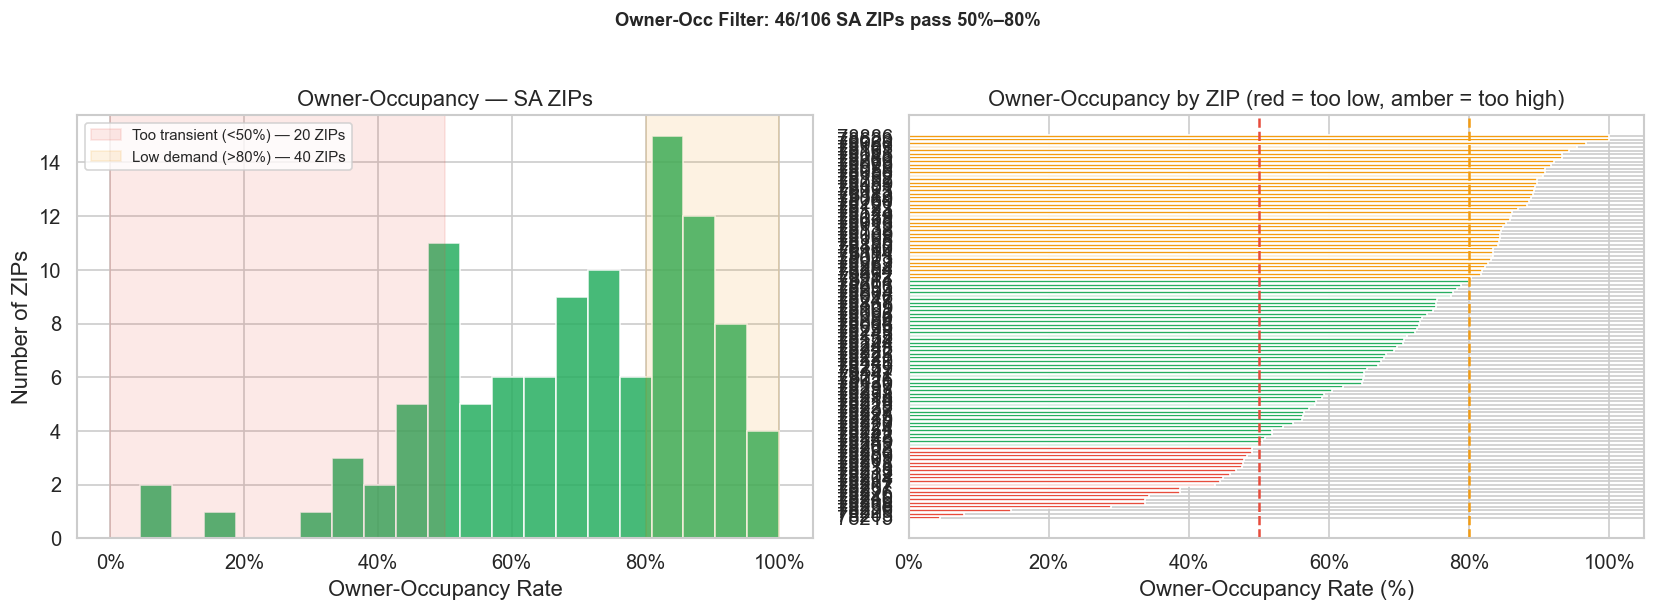

In [11]:
# 3.1 Owner-occupancy distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
min_occ = THRESHOLDS['min_owner_occ_pct']
max_occ = THRESHOLDS['max_owner_occ_pct']
n_low  = (census_sa['owner_occ_pct'] < min_occ).sum()
n_high = (census_sa['owner_occ_pct'] > max_occ).sum()
n_pass_occ = census_sa['owner_occ_pct'].between(min_occ, max_occ).sum()

ax = axes[0]
ax.hist(census_sa['owner_occ_pct'] * 100, bins=20, color=PASS_COLOR, edgecolor='white', alpha=0.85)
ax.axvspan(0,            min_occ * 100, alpha=0.12, color=FAIL_COLOR, label=f'Too transient (<{min_occ:.0%}) — {n_low} ZIPs')
ax.axvspan(max_occ * 100, 100,          alpha=0.12, color=WARN_COLOR, label=f'Low demand (>{max_occ:.0%}) — {n_high} ZIPs')
ax.set_xlabel('Owner-Occupancy Rate')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Owner-Occupancy — SA ZIPs')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9)

ax2 = axes[1]
sorted_occ = census_sa.sort_values('owner_occ_pct')
occ_colors = [FAIL_COLOR if v < min_occ else WARN_COLOR if v > max_occ else PASS_COLOR
              for v in sorted_occ['owner_occ_pct']]
ax2.barh(sorted_occ['zip'], sorted_occ['owner_occ_pct'] * 100, color=occ_colors, edgecolor='white')
ax2.axvline(min_occ * 100, color=FAIL_COLOR, linewidth=1.5, linestyle='--')
ax2.axvline(max_occ * 100, color=WARN_COLOR, linewidth=1.5, linestyle='--')
ax2.set_xlabel('Owner-Occupancy Rate (%)')
ax2.set_title('Owner-Occupancy by ZIP (red = too low, amber = too high)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle(f'Owner-Occ Filter: {n_pass_occ}/{len(census_sa)} SA ZIPs pass {min_occ:.0%}–{max_occ:.0%}',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

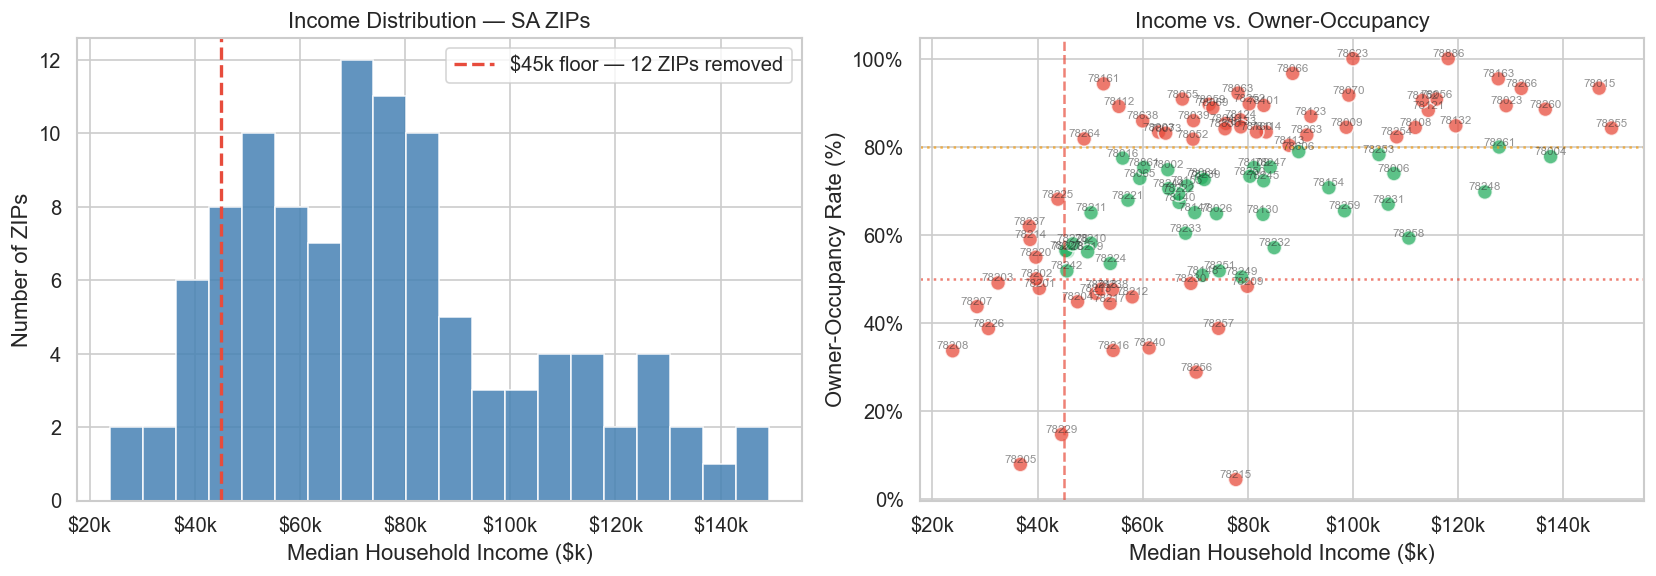

ZIPs cut by income filter only (5 total):
  zip  median_hh_income  owner_occ_pct
78237           38447.0       0.619620
78214           38591.0       0.589330
78220           39694.0       0.549075
78202           39759.0       0.500114
78225           43883.0       0.680810


In [12]:
# 3.2 Income distribution and income vs owner-occ relationship
income_floor  = THRESHOLDS['min_median_income']
census_income = census_sa.dropna(subset=['median_hh_income'])
n_pass_inc = (census_income['median_hh_income'] >= income_floor).sum()
n_fail_inc = (census_income['median_hh_income'] <  income_floor).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(census_income['median_hh_income'] / 1e3, bins=20,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(income_floor / 1e3, color=FAIL_COLOR, linewidth=2, linestyle='--',
           label=f'${income_floor/1e3:.0f}k floor — {n_fail_inc} ZIPs removed')
ax.set_xlabel('Median Household Income ($k)')
ax.set_ylabel('Number of ZIPs')
ax.set_title('Income Distribution — SA ZIPs')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax.legend()

ax2 = axes[1]
pt_colors = [
    FAIL_COLOR if (pd.notna(inc) and inc < income_floor) or occ < min_occ or occ > max_occ
    else PASS_COLOR
    for inc, occ in zip(census_sa['median_hh_income'], census_sa['owner_occ_pct'])
]
ax2.scatter(census_sa['median_hh_income'] / 1e3, census_sa['owner_occ_pct'] * 100,
            c=pt_colors, alpha=0.75, edgecolors='white', s=80)
for _, row in census_sa.iterrows():
    if pd.notna(row['median_hh_income']):
        ax2.annotate(row['zip'], (row['median_hh_income']/1e3, row['owner_occ_pct']*100),
                     fontsize=7, alpha=0.5, ha='center', va='bottom')
ax2.axvline(income_floor / 1e3, color=FAIL_COLOR, linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(min_occ * 100, color=FAIL_COLOR, linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axhline(max_occ * 100, color=WARN_COLOR, linestyle=':', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Median Household Income ($k)')
ax2.set_ylabel('Owner-Occupancy Rate (%)')
ax2.set_title('Income vs. Owner-Occupancy')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

# ZIPs cut ONLY by income — would pass owner-occ filter otherwise
income_only_cut = census_sa[
    census_sa['median_hh_income'].notna() &
    (census_sa['median_hh_income'] < income_floor) &
    (census_sa['owner_occ_pct'].between(min_occ, max_occ))
].sort_values('median_hh_income')
print(f"ZIPs cut by income filter only ({len(income_only_cut)} total):")
if len(income_only_cut) > 0:
    print(income_only_cut[['zip','median_hh_income','owner_occ_pct']].to_string(index=False))

**What to look for:** ZIPs cut *only* by income (bottom table) are worth examining by name. If you recognize any as legitimate house-hack targets, the $45k floor may be set too tightly. If they're all areas you'd immediately avoid, the filter is working as intended. The scatter plot should show a positive correlation between income and owner-occupancy — ZIPs that break that pattern are worth a second look.

---
## 4. SAPD Calls for Service (Crime)

**Source:** `sa_crime_raw.csv` — 5.3M SAPD dispatch records.

This is the most impactful and most uncertain data source. The model filters 5.3M rows to ~191k criminal incidents using a Problem-type allowlist. Everything downstream depends on that filter being correct.

**Questions:**
- What does the full Problem type distribution look like? Is 3.6% criminal rate plausible?
- Are there types in the allowlist that seem too minor? Types not in it that should be?
- What happens to the crime-per-1k distribution before vs. after filtering?
- Are there temporal artifacts that suggest data quality issues?

> ⚠️ **Performance note:** 600MB, 5.3M rows. Cells below use column subsetting. Expect 30–60s for the load cell.

Loading crime data (30–60 seconds)...


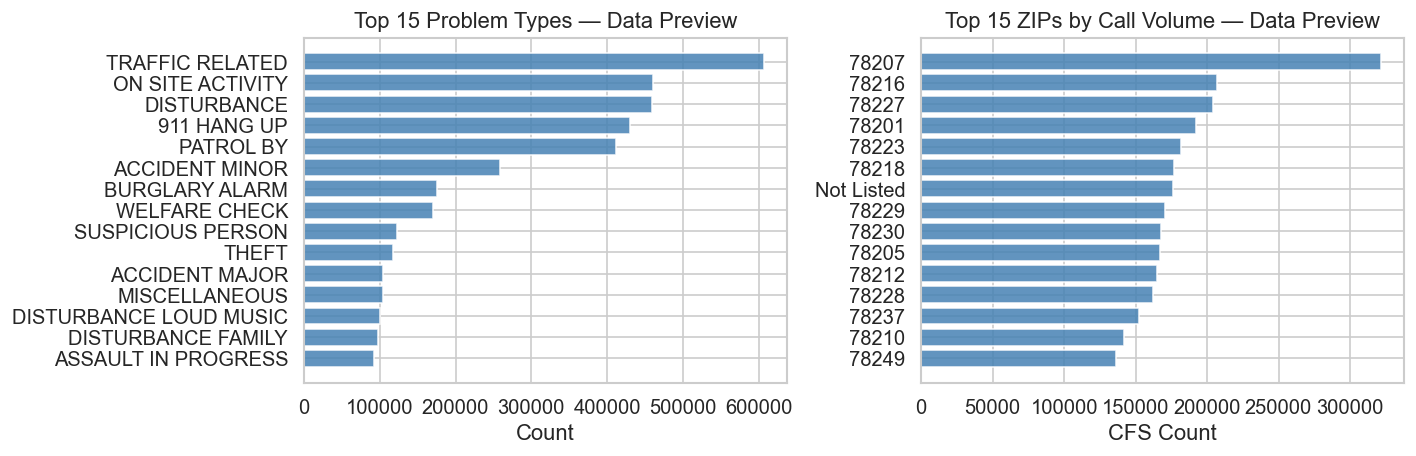

Total rows: 5,322,426
Unique ZIPs: 78
Unique Problem types: 154
Date range: 2023-01-01 00:00:12.000 to 2026-01-31 23:59:58.000


In [13]:
# Load crime — only the columns needed for EDA
CRIME_COLS = ['Priority', 'Problem', 'Postal_Code', 'Response_Date', 'Weekday']
print("Loading crime data (30–60 seconds)...")

crime_raw = pd.read_csv(
    DATA_RAW / 'sa_crime_raw.csv',
    usecols=lambda c: c in CRIME_COLS,
    dtype={'Postal_Code': str},
    low_memory=False
)
crime_raw['Postal_Code'] = crime_raw['Postal_Code'].str.strip().str.zfill(5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Problem type distribution (top 15)
problem_preview = crime_raw['Problem'].str.upper().str.strip().value_counts().head(15)
axes[0].barh(problem_preview.index[::-1], problem_preview.values[::-1], 
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Problem Types — Data Preview')

# Postal code coverage
zip_counts = crime_raw['Postal_Code'].value_counts().head(15)
axes[1].barh(zip_counts.index[::-1], zip_counts.values[::-1],
             color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('CFS Count')
axes[1].set_title('Top 15 ZIPs by Call Volume — Data Preview')

plt.tight_layout()
plt.show()

print(f"Total rows: {len(crime_raw):,}")
print(f"Unique ZIPs: {crime_raw['Postal_Code'].nunique()}")
print(f"Unique Problem types: {crime_raw['Problem'].nunique()}")
print(f"Date range: {crime_raw['Response_Date'].min()} to {crime_raw['Response_Date'].max()}")

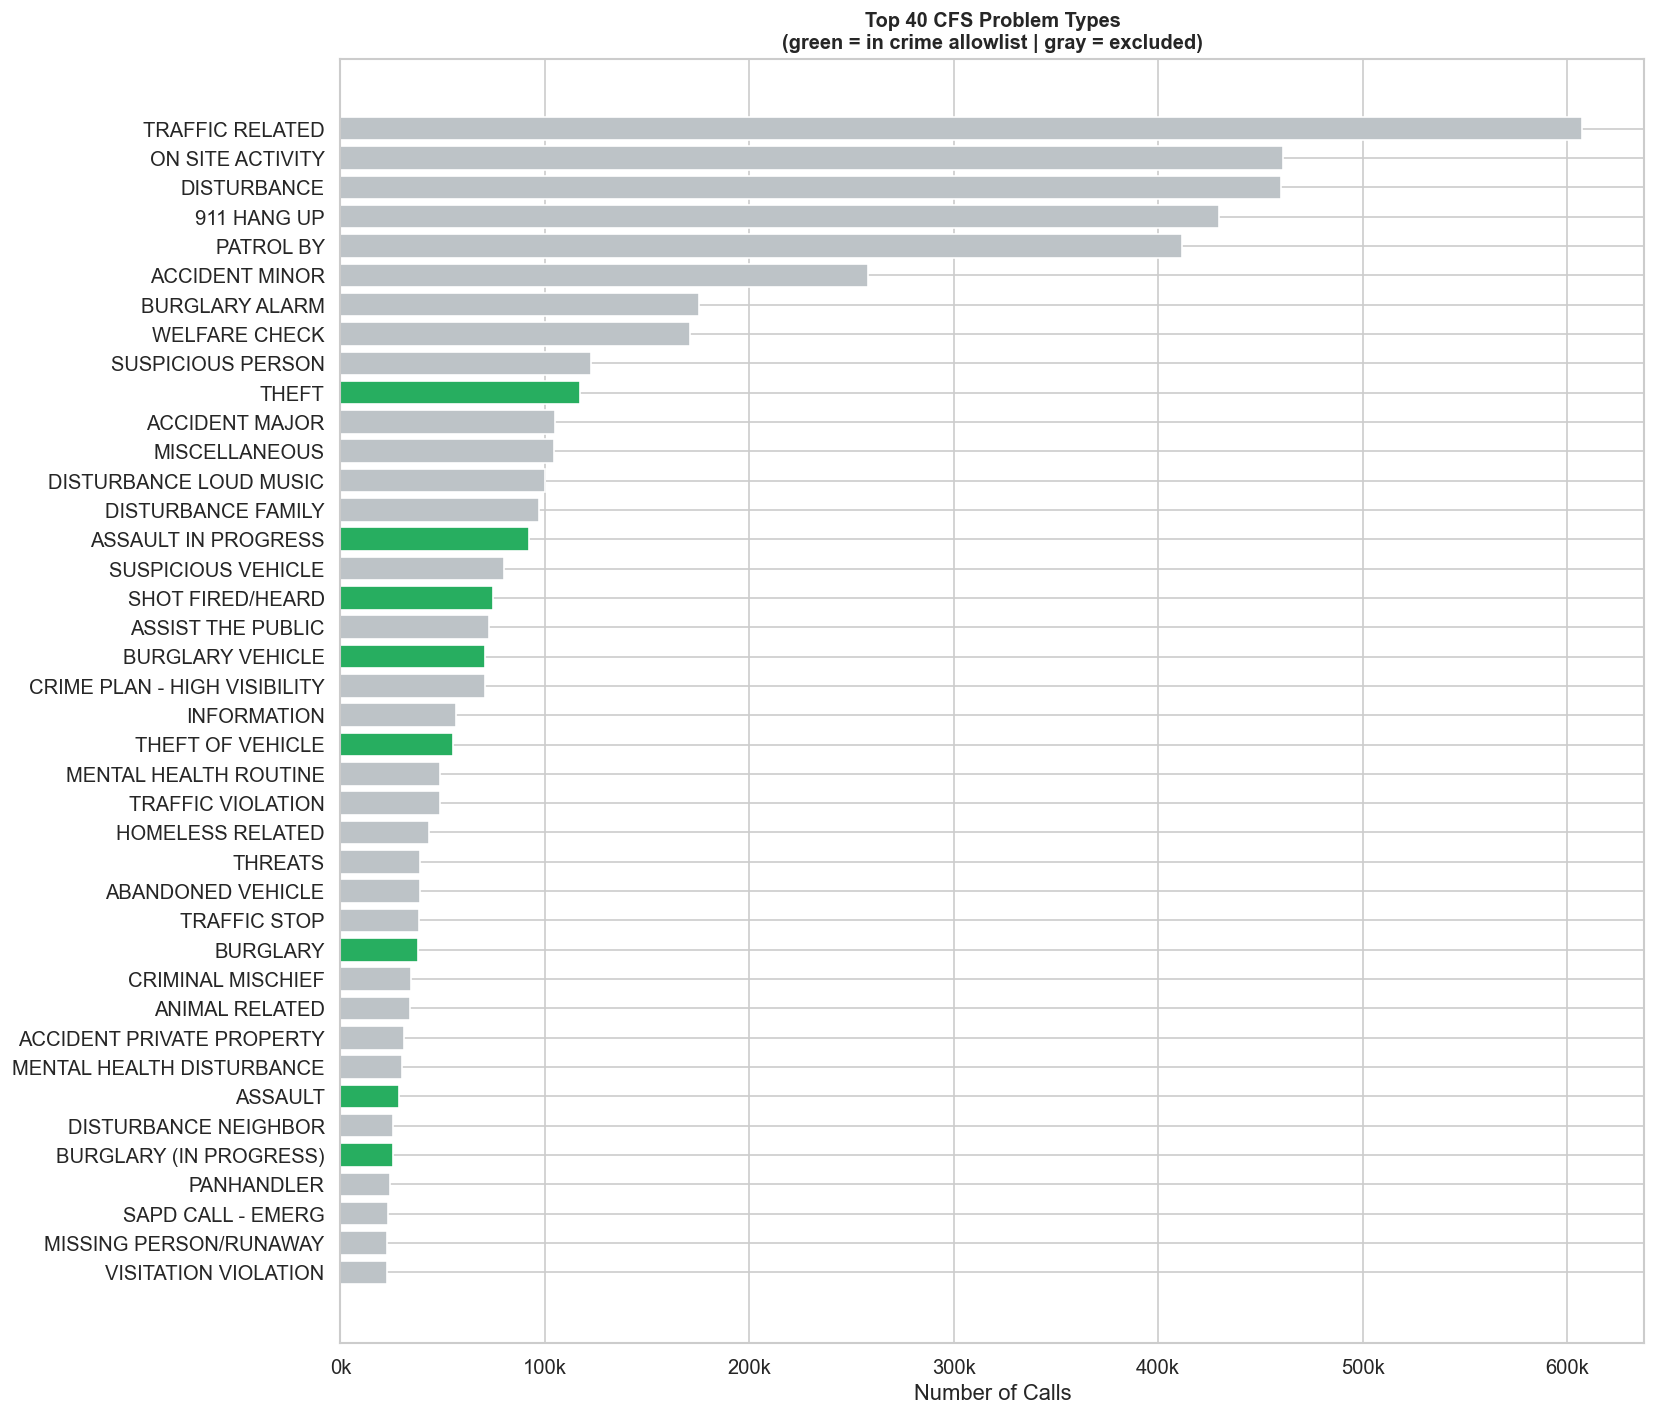

In allowlist:     702,240 calls (13.2%)
Not in list:    4,620,186 calls (86.8%)

✓ All allowlist types found in data.


In [14]:
# 4.1 Problem type distribution — the single most important chart in this notebook
# Green = in allowlist (counted as crime), gray = excluded
problem_counts  = crime_raw['Problem'].str.upper().str.strip().value_counts()
top_40          = problem_counts.head(40)
allowlist_upper = {p.upper() for p in VIOLENT_CRIME_PROBLEMS}
colors_prob     = [PASS_COLOR if p in allowlist_upper else '#bdc3c7' for p in top_40.index]

fig, ax = plt.subplots(figsize=(14, 12))
ax.barh(top_40.index[::-1], top_40.values[::-1], color=colors_prob[::-1], edgecolor='white')
ax.set_xlabel('Number of Calls')
ax.set_title('Top 40 CFS Problem Types\n(green = in crime allowlist | gray = excluded)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.show()

in_list  = problem_counts[problem_counts.index.isin(allowlist_upper)]
not_list = problem_counts[~problem_counts.index.isin(allowlist_upper)]
pct_in   = in_list.sum() / len(crime_raw) * 100

print(f"In allowlist:  {in_list.sum():>10,} calls ({pct_in:.1f}%)")
print(f"Not in list:   {not_list.sum():>10,} calls ({100-pct_in:.1f}%)")

missing_types = allowlist_upper - set(problem_counts.index)
if missing_types:
    print(f"\n⚠ Allowlist types NOT found in data (possible spelling mismatch):")
    for t in sorted(missing_types):
        print(f"  '{t}'")
else:
    print("\n✓ All allowlist types found in data.")

**What to look for:** Look carefully at the top gray bars — are they all clearly non-criminal (MEDICAL EMERGENCY, WELFARE CHECK, NOISE DISTURBANCE, TRAFFIC STOP)? If you see a large gray bar for something that sounds criminal (CRIMINAL TRESPASSING, STALKING, HARASSMENT), add it to `VIOLENT_CRIME_PROBLEMS` in `config.py`. If you see a large green bar for something minor (CRIMINAL MISCHIEF can be graffiti), consider removing it.

The "allowlist types NOT found in data" warning is important — it means your config references problem types that use different wording in the actual dataset. Fix the spelling.

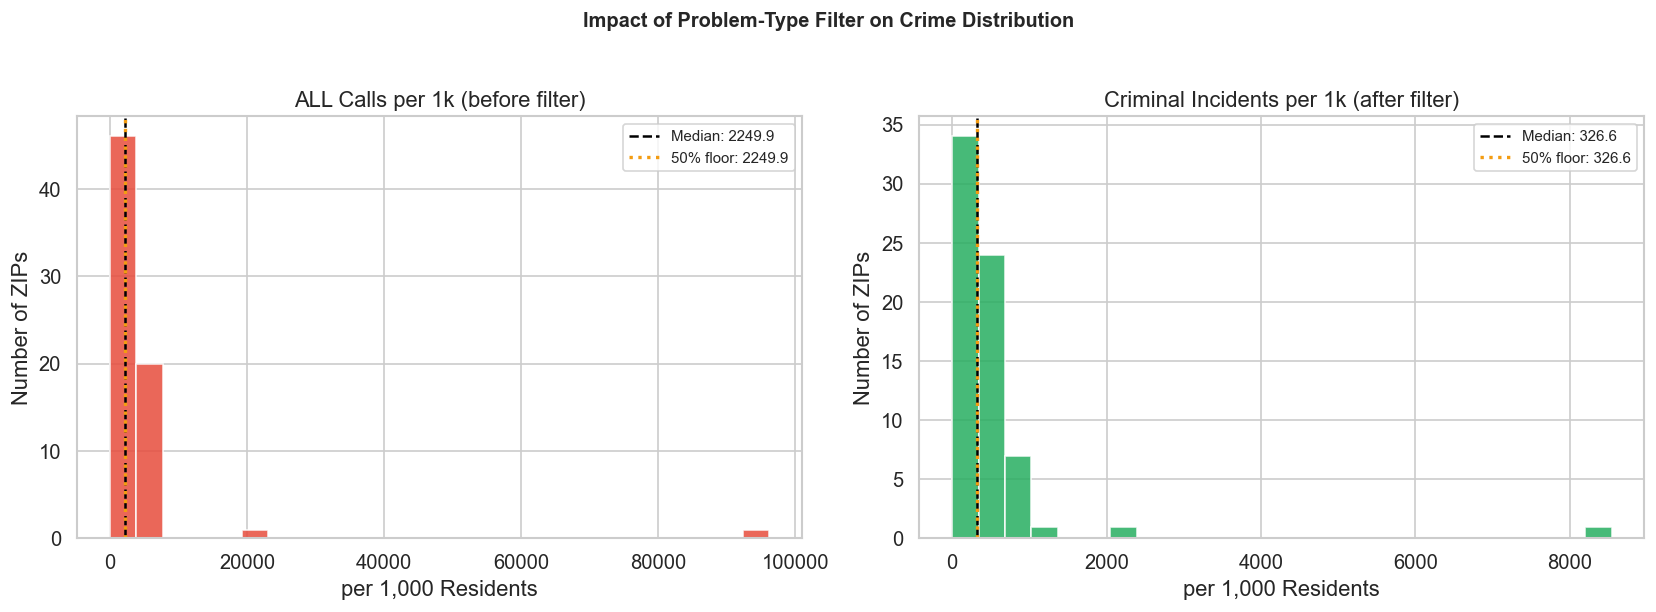

Before filter:
count       68.0
mean      4122.1
std      11717.8
min          0.0
25%        514.9
50%       2249.9
75%       4302.0
max      96174.0
Name: per_1k_all, dtype: str

After filter:
count      68.0
mean      487.4
std      1050.4
min         0.0
25%        58.2
50%       326.6
75%       580.2
max      8540.5
Name: per_1k_filt, dtype: str


In [ ]:
# 4.2 Crime per-1k distribution: before vs after Problem filter
military_zips = {'78234','78235','78236','78243'}
crime_clean   = crime_raw[~crime_raw['Postal_Code'].isin(military_zips)]
census_pop    = census_valid[['zip','population']].dropna().copy()

counts_all  = crime_clean.groupby('Postal_Code').size().reset_index(name='count_all')
counts_all['zip'] = counts_all['Postal_Code']

crime_filt  = crime_clean[crime_clean['Problem'].str.upper().str.strip().isin(allowlist_upper)]
counts_filt = crime_filt.groupby('Postal_Code').size().reset_index(name='count_filt')
counts_filt['zip'] = counts_filt['Postal_Code']

crime_comp = counts_all.merge(counts_filt, on='zip', how='outer').fillna(0)
crime_comp = crime_comp.merge(census_pop, on='zip', how='left')
crime_comp = crime_comp[crime_comp['population'] > 0].copy()
crime_comp['per_1k_all']  = crime_comp['count_all']  / crime_comp['population'] * 1000
crime_comp['per_1k_filt'] = crime_comp['count_filt'] / crime_comp['population'] * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, color in [
    (axes[0], 'per_1k_all',  'ALL Calls per 1k (before filter)',           FAIL_COLOR),
    (axes[1], 'per_1k_filt', 'Criminal Incidents per 1k (after filter)',    PASS_COLOR),
]:
    data         = crime_comp[col].dropna()
    pct_cutoff   = data.quantile(CRIME_PERCENTILE_CUTOFF)
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linewidth=1.5, linestyle='--',
               label=f'Median: {data.median():.1f}')
    ax.axvline(pct_cutoff, color=WARN_COLOR, linewidth=2, linestyle=':',
               label=f'{CRIME_PERCENTILE_CUTOFF:.0%} floor: {pct_cutoff:.1f}')
    ax.set_xlabel('per 1,000 Residents')
    ax.set_ylabel('Number of ZIPs')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Impact of Problem-Type Filter on Crime Distribution', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Before filter:")
print(crime_comp['per_1k_all'].describe().apply(lambda x: f'{x:.1f}'))
print("\nAfter filter:")
print(crime_comp['per_1k_filt'].describe().apply(lambda x: f'{x:.1f}'))

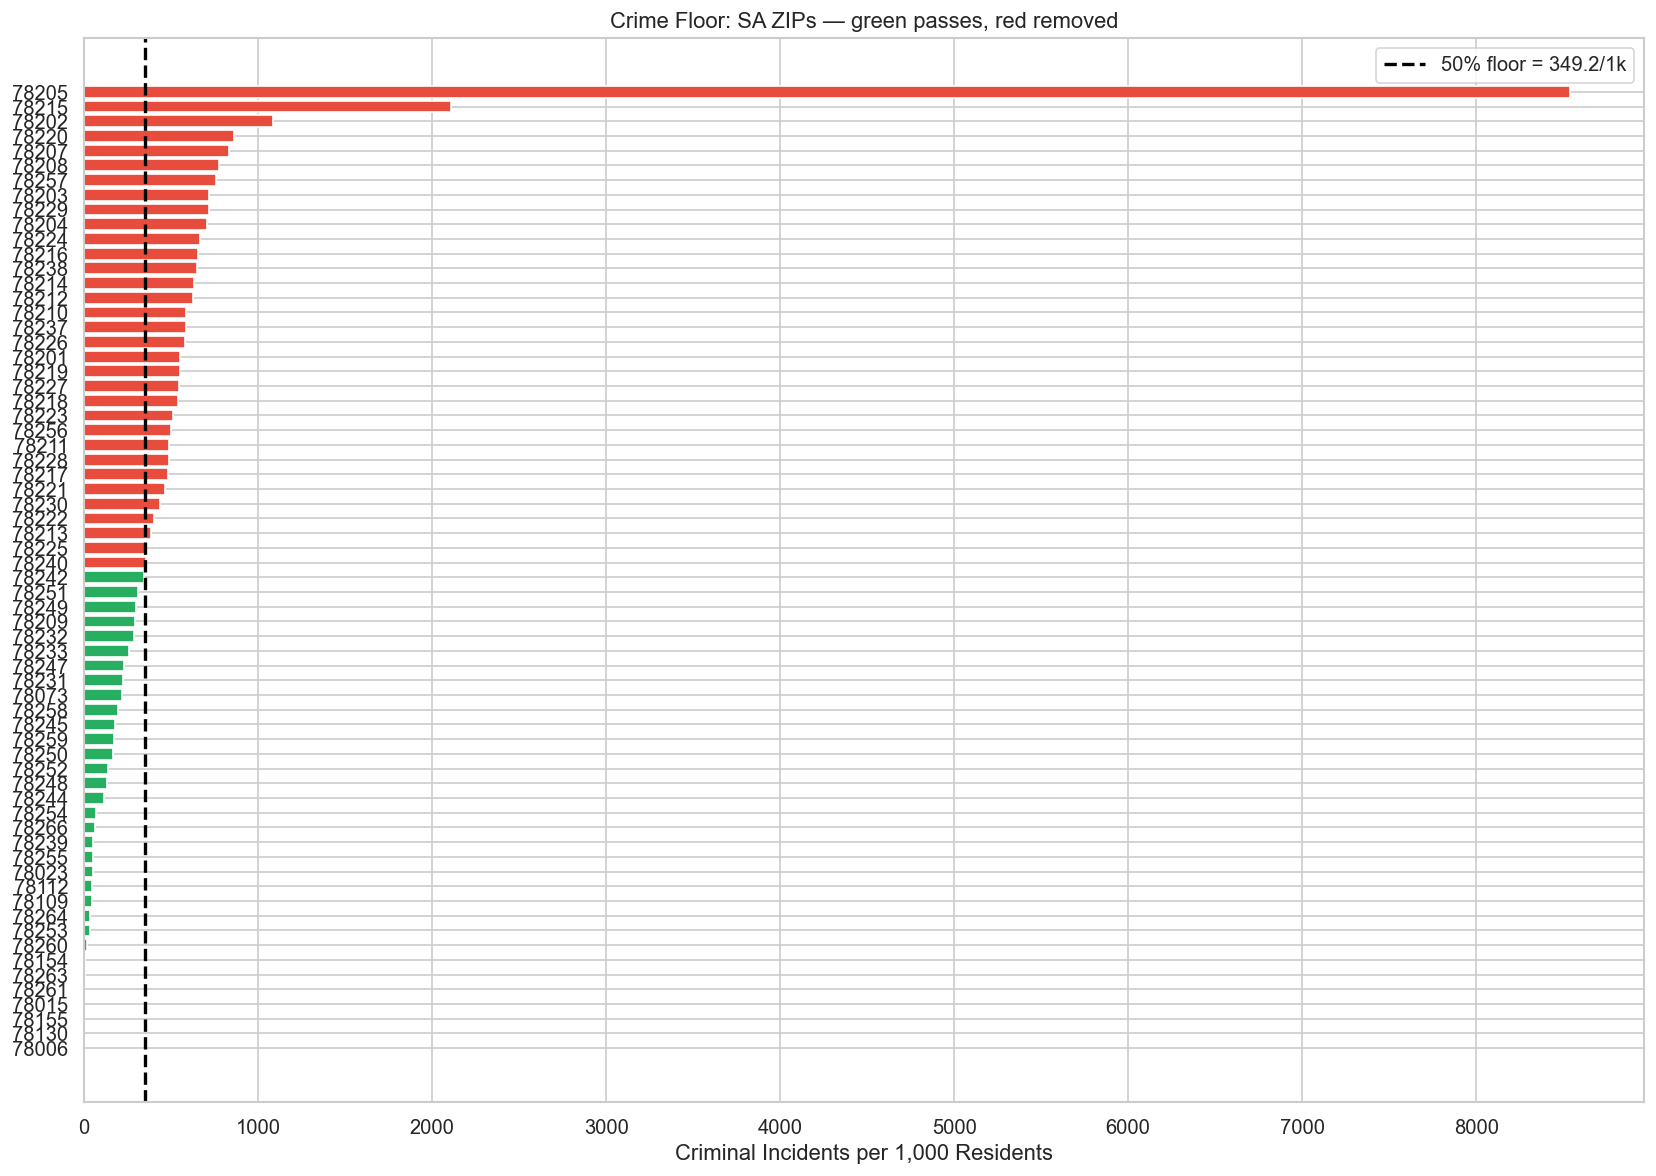

Crime floor threshold: 349.24 per 1k
SA ZIPs passing: 33 of 66


In [23]:
# 4.3 Crime floor — which SA ZIPs survive the 50th percentile cut?
sa_crime    = crime_comp[crime_comp['zip'].isin(sa_zips)].copy()
crime_floor = sa_crime['per_1k_filt'].quantile(CRIME_PERCENTILE_CUTOFF)

sorted_crime = sa_crime.sort_values('per_1k_filt')
bar_col_c    = [PASS_COLOR if v <= crime_floor else FAIL_COLOR
                for v in sorted_crime['per_1k_filt']]

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(sorted_crime['zip'], sorted_crime['per_1k_filt'], color=bar_col_c, edgecolor='white')
ax.axvline(crime_floor, color='black', linewidth=2, linestyle='--',
           label=f'{CRIME_PERCENTILE_CUTOFF:.0%} floor = {crime_floor:.1f}/1k')
ax.set_xlabel('Criminal Incidents per 1,000 Residents')
ax.set_title(f'Crime Floor: SA ZIPs — green passes, red removed')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Crime floor threshold: {crime_floor:.2f} per 1k")
print(f"SA ZIPs passing: {(sa_crime['per_1k_filt'] <= crime_floor).sum()} of {len(sa_crime)}")

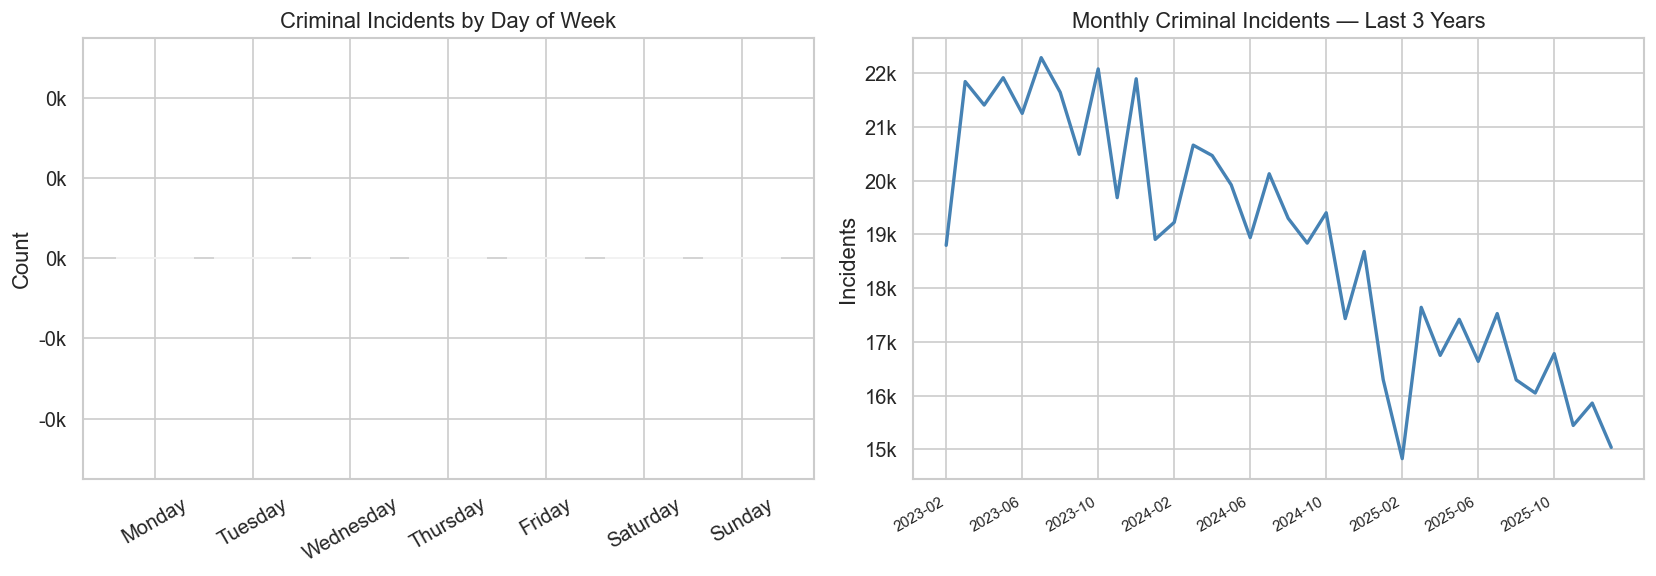

Tip: A sharp drop in the most recent months = incomplete data. That month's crime would be undercounted.


In [24]:
# 4.4 Temporal patterns — data quality check
crime_filt_sa = crime_filt[crime_filt['Postal_Code'].isin(sa_zips)].copy()
fig, axes     = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
if 'Weekday' in crime_filt_sa.columns:
    day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    day_counts = crime_filt_sa['Weekday'].value_counts().reindex(day_order, fill_value=0)
    axes[0].bar(day_counts.index, day_counts.values, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].set_title('Criminal Incidents by Day of Week')
    axes[0].set_ylabel('Count')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    axes[0].tick_params(axis='x', rotation=30)

# Monthly trend — look for sudden drops that indicate incomplete data
if 'Response_Date' in crime_filt_sa.columns:
    crime_filt_sa['Response_Date'] = pd.to_datetime(crime_filt_sa['Response_Date'], errors='coerce')
    crime_filt_sa['month'] = crime_filt_sa['Response_Date'].dt.to_period('M')
    monthly = crime_filt_sa.groupby('month').size().sort_index().tail(36)
    monthly = monthly[monthly.index.notna()]
    axes[1].plot(range(len(monthly)), monthly.values, color='steelblue', linewidth=2)
    tick_step = max(1, len(monthly) // 8)
    axes[1].set_xticks(range(0, len(monthly), tick_step))
    axes[1].set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), tick_step)],
                             rotation=30, ha='right', fontsize=9)
    axes[1].set_title('Monthly Criminal Incidents — Last 3 Years')
    axes[1].set_ylabel('Incidents')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.show()
print("Tip: A sharp drop in the most recent months = incomplete data. That month's crime would be undercounted.")

---
## 5. Cross-Source: ZIP Overlap & Filter Funnel

The model inner-joins all five data sources — a ZIP must appear in all of them to be scored. Understanding where ZIPs drop out shows whether gaps are random or systematic.

**The filter funnel** tracks how many ZIPs survive each stage, from raw data through every filter to the final scored pool.

In [18]:
# 5.1 ZIP overlap by source
sets = {
    'ZHVI':      set(zhvi_sa['zip']),
    'ZORI':      set(zori_sa['zip']),
    'Census':    set(census_sa['zip']),
    'Crime':     set(sa_crime['zip']),
    'Stability': set(zhvi_sa[zhvi_sa['cov'].notna()]['zip']),
}

print("ZIP coverage by source (overlap with ZHVI):")
for name, s in sets.items():
    overlap = len(s & sets['ZHVI'])
    print(f"  {name:<12}: {len(s):>4} total | {overlap:>4} in ZHVI")

print("\nZIPs in ZHVI with no ZORI rent data:")
print(sorted(sets['ZHVI'] - sets['ZORI']))

print("\nZIPs in ZHVI with no crime data:")
print(sorted(sets['ZHVI'] - sets['Crime']))

ZIP coverage by source (overlap with ZHVI):
  ZHVI        :  106 total |  106 in ZHVI
  ZORI        :   70 total |   69 in ZHVI
  Census      :  106 total |  106 in ZHVI
  Crime       :   66 total |   66 in ZHVI
  Stability   :  106 total |  106 in ZHVI

ZIPs in ZHVI with no ZORI rent data:
['78002', '78003', '78004', '78009', '78013', '78016', '78026', '78039', '78052', '78055', '78056', '78059', '78063', '78064', '78065', '78066', '78069', '78101', '78112', '78113', '78114', '78121', '78123', '78124', '78140', '78147', '78160', '78161', '78226', '78263', '78264', '78606', '78623', '78638', '78850', '78861', '78886']

ZIPs in ZHVI with no crime data:
['78002', '78003', '78004', '78009', '78013', '78016', '78026', '78039', '78052', '78055', '78056', '78059', '78063', '78064', '78065', '78066', '78069', '78070', '78101', '78108', '78113', '78114', '78121', '78123', '78124', '78132', '78133', '78140', '78147', '78148', '78152', '78160', '78161', '78163', '78606', '78623', '78638', '78850

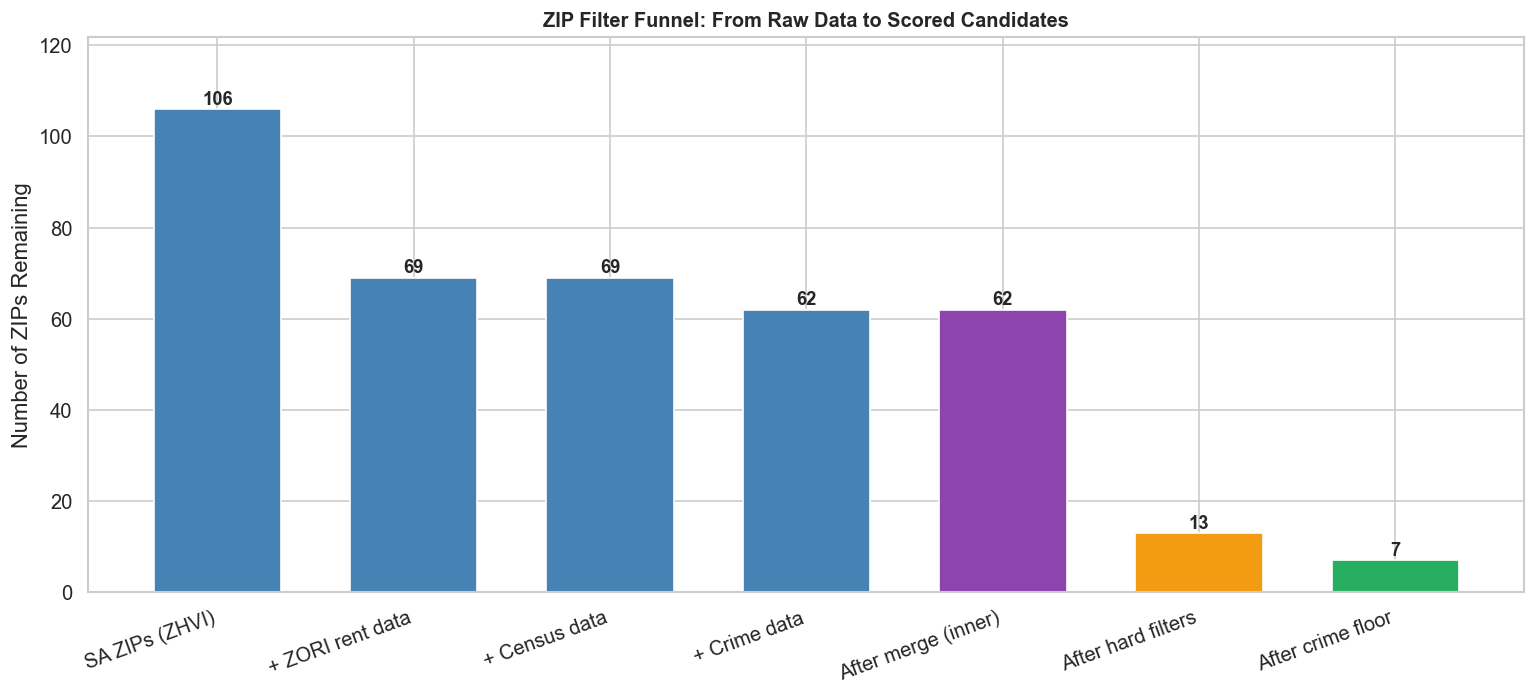


Funnel stage summary:
  SA ZIPs (ZHVI)                : 106
  + ZORI rent data              : 69
  + Census data                 : 69
  + Crime data                  : 62
  After merge (inner)           : 62
  After hard filters            : 13
  After crime floor             : 7


In [19]:
# 5.2 Filter funnel waterfall
# Reconstruct the pipeline stages to show cumulative ZIP loss

merged_full = merged_yield.merge(
    census_sa[['zip','owner_occ_pct','median_hh_income']], on='zip', how='inner')
merged_full = merged_full.merge(
    sa_crime[['zip','per_1k_filt']].rename(columns={'per_1k_filt':'crime_per_1k'}), on='zip', how='inner')

merged_full['pass_yield']  = merged_full['rent_to_price'] >= THRESHOLDS['min_rent_to_price']
merged_full['pass_price']  = merged_full['current_value'] <= THRESHOLDS['max_home_value']
merged_full['pass_occ_lo'] = merged_full['owner_occ_pct'] >= THRESHOLDS['min_owner_occ_pct']
merged_full['pass_occ_hi'] = merged_full['owner_occ_pct'] <= THRESHOLDS['max_owner_occ_pct']
merged_full['pass_income'] = (
    merged_full['median_hh_income'].isna() |
    (merged_full['median_hh_income'] >= THRESHOLDS['min_median_income'])
)
all_hard = (merged_full['pass_yield'] & merged_full['pass_price'] &
            merged_full['pass_occ_lo'] & merged_full['pass_occ_hi'] & merged_full['pass_income'])

crime_threshold = merged_full.loc[all_hard, 'crime_per_1k'].quantile(CRIME_PERCENTILE_CUTOFF)

stage_zori   = sets['ZHVI'] & sets['ZORI']
stage_census = stage_zori & sets['Census']
stage_crime  = stage_census & sets['Crime']
stage_merged = set(merged_full['zip'])

stages = [
    ('SA ZIPs (ZHVI)',       len(sets['ZHVI'])),
    ('+ ZORI rent data',     len(stage_zori)),
    ('+ Census data',        len(stage_census)),
    ('+ Crime data',         len(stage_crime)),
    ('After merge (inner)',  len(stage_merged)),
    ('After hard filters',   int(all_hard.sum())),
    ('After crime floor',    int((all_hard & (merged_full['crime_per_1k'] <= crime_threshold)).sum())),
]

labels = [s[0] for s in stages]
values = [s[1] for s in stages]

fig, ax = plt.subplots(figsize=(13, 6))
bar_colors = ['steelblue'] * 4 + ['#8e44ad', WARN_COLOR, PASS_COLOR]
bars = ax.bar(labels, values, color=bar_colors, edgecolor='white', width=0.65)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Number of ZIPs Remaining')
ax.set_title('ZIP Filter Funnel: From Raw Data to Scored Candidates', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print("\nFunnel stage summary:")
for label, val in stages:
    print(f"  {label:<30}: {val}")

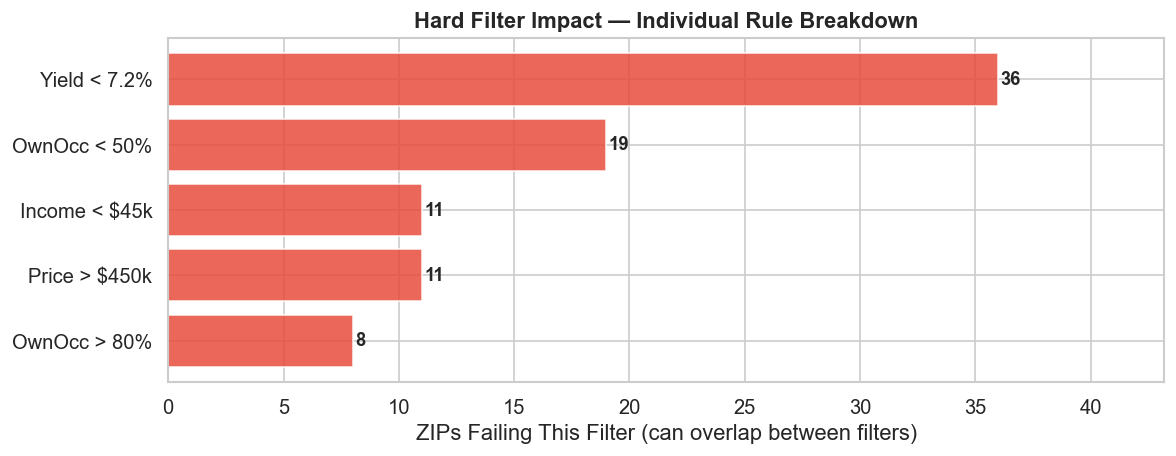

Total ZIPs removed by hard filters: 49
Surviving: 13


In [20]:
# 5.3 Individual filter impact — which rule is most constraining?
filter_audit = {
    f'Yield < {THRESHOLDS["min_rent_to_price"]:.1%}':      (~merged_full['pass_yield']).sum(),
    f'Price > ${THRESHOLDS["max_home_value"]/1e3:.0f}k':   (~merged_full['pass_price']).sum(),
    f'OwnOcc < {THRESHOLDS["min_owner_occ_pct"]:.0%}':     (~merged_full['pass_occ_lo']).sum(),
    f'OwnOcc > {THRESHOLDS["max_owner_occ_pct"]:.0%}':     (~merged_full['pass_occ_hi']).sum(),
    f'Income < ${THRESHOLDS["min_median_income"]/1e3:.0f}k': (~merged_full['pass_income']).sum(),
}
audit_df = pd.Series(filter_audit).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(audit_df.index, audit_df.values, color=FAIL_COLOR, edgecolor='white', alpha=0.85)
for i, val in enumerate(audit_df.values):
    ax.text(val + 0.1, i, str(val), va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('ZIPs Failing This Filter (can overlap between filters)')
ax.set_title('Hard Filter Impact — Individual Rule Breakdown', fontweight='bold')
ax.set_xlim(0, audit_df.max() * 1.2)
plt.tight_layout()
plt.show()

print(f"Total ZIPs removed by hard filters: {(~all_hard).sum()}")
print(f"Surviving: {all_hard.sum()}")

Final scored pool: 7 ZIPs

                   mean         50%         min         max
Yield             0.098       0.094       0.081       0.122
Home Value   196125.886  210774.226  151763.298  244062.708
Crime/1k        271.851     345.072      42.890     486.532
Owner-Occ         0.664       0.693       0.518       0.753
Med. Income   62030.143   64968.000   45589.000   81152.000


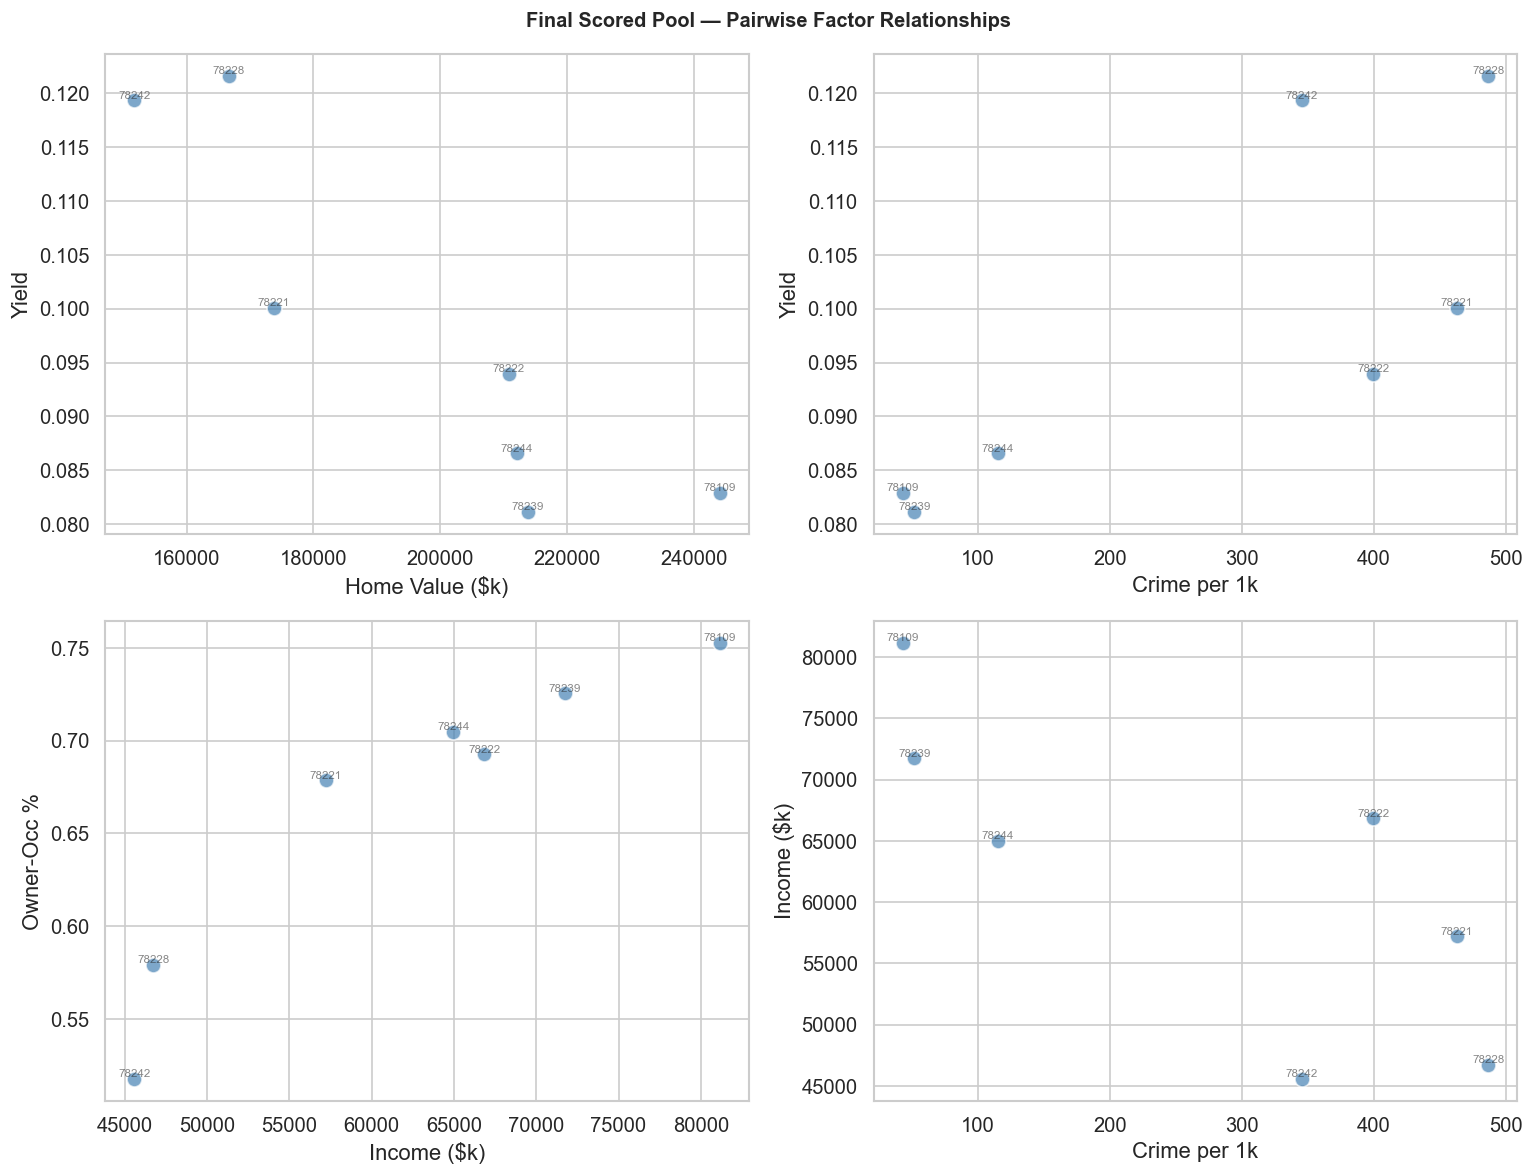

In [21]:
# 5.4 Final pool — multi-factor profile
final_pool = merged_full[all_hard & (merged_full['crime_per_1k'] <= crime_threshold)].copy()
print(f"Final scored pool: {len(final_pool)} ZIPs\n")

profile = final_pool[['rent_to_price','current_value','crime_per_1k','owner_occ_pct','median_hh_income']].describe().T
profile.index = ['Yield','Home Value','Crime/1k','Owner-Occ','Med. Income']
print(profile[['mean','50%','min','max']].round(3).to_string())

# Pairwise scatter: final pool factors
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
pairs = [
    ('current_value',   'rent_to_price',  'Home Value ($k)', 'Yield',        axes[0,0]),
    ('crime_per_1k',    'rent_to_price',  'Crime per 1k',    'Yield',        axes[0,1]),
    ('median_hh_income','owner_occ_pct',  'Income ($k)',     'Owner-Occ %',  axes[1,0]),
    ('crime_per_1k',    'median_hh_income','Crime per 1k',   'Income ($k)',  axes[1,1]),
]
for xcol, ycol, xlabel, ylabel, ax in pairs:
    ax.scatter(final_pool[xcol], final_pool[ycol],
               color='steelblue', alpha=0.7, edgecolors='white', s=80)
    for _, row in final_pool.iterrows():
        ax.annotate(row['zip'], (row[xcol], row[ycol]),
                    fontsize=7, alpha=0.55, ha='center', va='bottom')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
plt.suptitle('Final Scored Pool — Pairwise Factor Relationships', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Findings & Config Calibration Notes

Fill this in as you run the notebook. The goal is to end with concrete actions for `config.py`.

### ZHVI
- Home value ceiling ($450k): ___ ZIPs removed. Removed ZIPs: ___
- Most stable ZIP (lowest CoV): ___ | Least stable: ___
- 3-year appreciation range: ___% to ___%
- Does CoV spread ZIPs meaningfully? ___

### ZORI / Yield
- Yield floor (7.2%): ___ ZIPs removed of ___
- Borderline ZIPs (within 15% below floor): ___
- Rent trend over last 24 months: rising / flat / falling?

### Census
- Owner-occ filter: ___ ZIPs too low, ___ too high
- Income filter: ___ ZIPs removed
- ZIPs cut only by income (review by name): ___

### Crime
- Criminal incident % of total CFS calls: ___%
- Allowlist types missing from data (spelling mismatch): ___
- Problem types to ADD to allowlist: ___
- Problem types to REMOVE from allowlist: ___
- Crime floor threshold: ___ per 1k | ___ ZIPs removed
- Temporal anomaly (incomplete recent months?): ___

### Filter Funnel
- Biggest single ZIP loss stage: ___
- Final scored pool size: ___
- Most constraining individual filter: ___

### Suggested `config.py` Changes
- [ ] `min_rent_to_price`: change to ___
- [ ] `max_home_value`: change to ___
- [ ] `min_owner_occ_pct`: change to ___
- [ ] `min_median_income`: change to ___
- [ ] `CRIME_PERCENTILE_CUTOFF`: change to ___
- [ ] Add to `VIOLENT_CRIME_PROBLEMS`: ___
- [ ] Remove from `VIOLENT_CRIME_PROBLEMS`: ___